# Análisis Integrado con Datos Normalizados y Métricas Porcentuales
## Matrimonios · Violencia Intrafamiliar · Defunciones (Guatemala 2009-2020)

**Problema de Investigación:**  
*"Matrimonios que terminan en violencia intrafamiliar y que terminen en defunciones por violencia"*

---

## Por qué este notebook existe: el problema de Min-Max con outliers

La normalización **Min-Max transforma la escala pero preserva las proporciones relativas**. Si Guatemala capital tiene 15× más casos que Totonicapán, después de normalizar sigue teniendo 15× más (0.95 vs 0.06). Los gráficos se ven igual porque la dominancia estructural no cambia.

### Estrategia adoptada en este notebook

| Tipo de análisis | Técnica | Justificación |
|---|---|---|
| Series temporales | **Min-Max Robusto** (ref. 2009-2019) | Compara tendencias en escala común; 2020 marca el impacto COVID |
| Análisis geográfico | **% de participación intra-año** | Elimina efecto tamaño sin datos externos de población |
| Variables demográficas | **Distribuciones porcentuales** | Comparabilidad entre grupos de distinto tamaño |
| Correlaciones | **Tasas de cambio interanuales** | Elimina el nivel absoluto, compara movimientos |
| Clustering | **Features porcentuales** (CAGR, CV, rangos %) | Agrupa por intensidad relativa, no magnitud |

**Fuente de datos:** Instituto Nacional de Estadística (INE) de Guatemala  
**Fecha de análisis:** Febrero 2026

In [57]:
%pip install pandas numpy matplotlib seaborn scipy scikit-learn pyreadstat -q



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pyreadstat
from pathlib import Path
from scipy import stats
from scipy.stats import chi2_contingency, pearsonr, spearmanr
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 11
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.width', 160)

print("Librerías importadas correctamente")


Librerías importadas correctamente


---
## Sección 1 — Carga de Datasets Originales y Funciones de Normalización

Se cargan los archivos `.sav` originales (misma fuente que `caso_base.ipynb`) y se definen las funciones que construyen las métricas normalizadas/porcentuales que se usarán en todo el análisis.

In [59]:
print("="*80)
print("CARGANDO DATASETS ORIGINALES")
print("="*80)

departamentos_map = {
    1:'Guatemala', 2:'El Progreso', 3:'Sacatepéquez', 4:'Chimaltenango',
    5:'Escuintla', 6:'Santa Rosa', 7:'Sololá', 8:'Totonicapán',
    9:'Quetzaltenango', 10:'Suchitepéquez', 11:'Retalhuleu', 12:'San Marcos',
    13:'Huehuetenango', 14:'Quiché', 15:'Baja Verapaz', 16:'Alta Verapaz',
    17:'Petén', 18:'Izabal', 19:'Zacapa', 20:'Chiquimula',
    21:'Jalapa', 22:'Jutiapa'
}
TODOS_DEPTOS = list(departamentos_map.values())

# ── Defunciones ───────────────────────────────────────────────────────────────
archivos_def = sorted(Path('data/defunciones/sav').glob('*.sav'))
dfs = []
for f in archivos_def:
    df_t, _ = pyreadstat.read_sav(str(f))
    df_t['ANIO'] = int(f.stem.split('-')[0])
    dfs.append(df_t)
df_defunciones = pd.concat(dfs, ignore_index=True)
print(f"Defunciones       : {len(df_defunciones):>8,} registros  ({df_defunciones['ANIO'].min()}-{df_defunciones['ANIO'].max()})")

# ── Matrimonios ───────────────────────────────────────────────────────────────
archivos_mat = sorted(Path('data/matrimonios/sav').glob('*.sav'))
dfs = []
for f in archivos_mat:
    df_t, _ = pyreadstat.read_sav(str(f))
    df_t['ANIO'] = int(f.stem.split('-')[0])
    dfs.append(df_t)
df_matrimonios = pd.concat(dfs, ignore_index=True)
print(f"Matrimonios       : {len(df_matrimonios):>8,} registros  ({df_matrimonios['ANIO'].min()}-{df_matrimonios['ANIO'].max()})")

# ── Violencia Intrafamiliar ────────────────────────────────────────────────────
archivos_vio = sorted(Path('data/violencia-intrafamiliar').glob('*.sav'))
dfs = []
for f in archivos_vio:
    df_t, _ = pyreadstat.read_sav(str(f))
    df_t['ANIO'] = int(f.stem.split('-')[0])
    dfs.append(df_t)
df_violencia = pd.concat(dfs, ignore_index=True)
print(f"Violencia         : {len(df_violencia):>8,} registros  ({df_violencia['ANIO'].min()}-{df_violencia['ANIO'].max()})")

# ── Mapear departamentos ───────────────────────────────────────────────────────
# Defunciones y Matrimonios: columna DEPREG* tiene código 1-22 directamente
for df_src, kw in [(df_defunciones, 'DEPREG'), (df_matrimonios, 'DEPREG')]:
    for col in df_src.columns:
        if kw in col.upper():
            df_src['Departamento'] = df_src[col].map(departamentos_map)
            break

# Violencia: DEPTO_MCPIO usa código dept-municipio (ej. 101=Guatemala/01)
# Extraer departamento dividiendo entre 100
_col_vio = 'DEPTO_MCPIO'
df_violencia['Departamento'] = (
    df_violencia[_col_vio]
    .dropna()
    .astype(int)
    .floordiv(100)
    .map(departamentos_map)
    .reindex(df_violencia.index)
)

for ds_name, df_src in [('Defunciones', df_defunciones),
                         ('Matrimonios', df_matrimonios),
                         ('Violencia',   df_violencia)]:
    ok  = df_src['Departamento'].notna().sum()
    pct = ok / len(df_src) * 100
    print(f"  {ds_name:12}: {ok:>8,} registros mapeados ({pct:.1f}%)")

print("\nMapeo de departamentos aplicado a los tres datasets.")
print("="*80)


CARGANDO DATASETS ORIGINALES
Defunciones       :  963,770 registros  (2009-2020)
Matrimonios       :  887,492 registros  (2009-2020)
Violencia         :  387,257 registros  (2009-2020)
  Defunciones :  963,770 registros mapeados (100.0%)
  Matrimonios :  736,082 registros mapeados (82.9%)
  Violencia   :  387,257 registros mapeados (100.0%)

Mapeo de departamentos aplicado a los tres datasets.


In [60]:
print("="*80)
print("FUNCIONES DE TRANSFORMACIÓN CENTRAL")
print("="*80)

AÑOS = list(range(2009, 2021))

# ── 1. Series anuales absolutas ────────────────────────────────────────────────
def serie_anual(df, col_anio='ANIO'):
    return df.groupby(col_anio).size().reindex(AÑOS, fill_value=0)

matrimonios_anual  = serie_anual(df_matrimonios)
violencia_anual    = serie_anual(df_violencia)
defunciones_anual  = serie_anual(df_defunciones)

df_tendencias = pd.DataFrame({
    'Año': AÑOS,
    'Matrimonios': matrimonios_anual.values,
    'Violencia': violencia_anual.values,
    'Defunciones': defunciones_anual.values,
})

# ── 2. Min-Max Robusto (referencia 2009-2019, 2020 proyectado) ─────────────────
def minmax_robusto(series, excluir_año=2020, años=AÑOS):
    ref = [v for a, v in zip(años, series) if a != excluir_año]
    mn, mx = min(ref), max(ref)
    return [(v - mn) / (mx - mn) if mx != mn else 0 for v in series]

for col in ['Matrimonios', 'Violencia', 'Defunciones']:
    df_tendencias[col + '_MM'] = minmax_robusto(df_tendencias[col])

# ── 3. Tasa de variación interanual (pct_change) ───────────────────────────────
for col in ['Matrimonios', 'Violencia', 'Defunciones']:
    df_tendencias[col + '_PctChange'] = (
        pd.Series(df_tendencias[col].values)
        .pct_change()
        .fillna(0)
        .values * 100
    )

# ── 4. Índice base 2009 = 100 ──────────────────────────────────────────────────
for col in ['Matrimonios', 'Violencia', 'Defunciones']:
    base = df_tendencias.loc[df_tendencias['Año'] == 2009, col].values[0]
    df_tendencias[col + '_Idx'] = df_tendencias[col] / base * 100

# ── 5. Participación porcentual intra-año por departamento ────────────────────
def pct_intra_anio(df, col_depto='Departamento', col_anio='ANIO'):
    """Calcula % que representa cada depto del total nacional de ese año."""
    conteo = df.groupby([col_anio, col_depto]).size().reset_index(name='Casos')
    total_anio = conteo.groupby(col_anio)['Casos'].transform('sum')
    conteo['PctNacional'] = conteo['Casos'] / total_anio * 100
    return conteo

pct_def = pct_intra_anio(df_defunciones)
pct_vio = pct_intra_anio(df_violencia)
pct_mat = pct_intra_anio(df_matrimonios)

# Promedio 2009-2020 por departamento (excluyendo 2020 del cálculo de referencia)
def pct_promedio_depto(pct_df, excluir=2020):
    ref = pct_df[pct_df['ANIO'] != excluir]
    return ref.groupby('Departamento')['PctNacional'].mean().sort_values(ascending=False)

pct_prom_def = pct_promedio_depto(pct_def)
pct_prom_vio = pct_promedio_depto(pct_vio)
pct_prom_mat = pct_promedio_depto(pct_mat)

print("Funciones definidas:")
print("  • minmax_robusto()      → Min-Max con referencia 2009-2019")
print("  • pct_intra_anio()      → % de participación por departamento en cada año")
print("  • df_tendencias         → Series anuales con cols _MM, _PctChange, _Idx")
print("  • pct_def / pct_vio / pct_mat → DataFrames de participación porcentual")
print("="*80)


FUNCIONES DE TRANSFORMACIÓN CENTRAL
Funciones definidas:
  • minmax_robusto()      → Min-Max con referencia 2009-2019
  • pct_intra_anio()      → % de participación por departamento en cada año
  • df_tendencias         → Series anuales con cols _MM, _PctChange, _Idx
  • pct_def / pct_vio / pct_mat → DataFrames de participación porcentual


---
## Sección 2 — Min-Max vs Tasas Porcentuales: por qué la normalización sola no resuelve los outliers

Esta sección demuestra visualmente que Min-Max no cambia el patrón percibido en series con outliers estructurales (como 2020/COVID), mientras que las **tasas de variación interanual** sí revelan la magnitud real del cambio relativo.

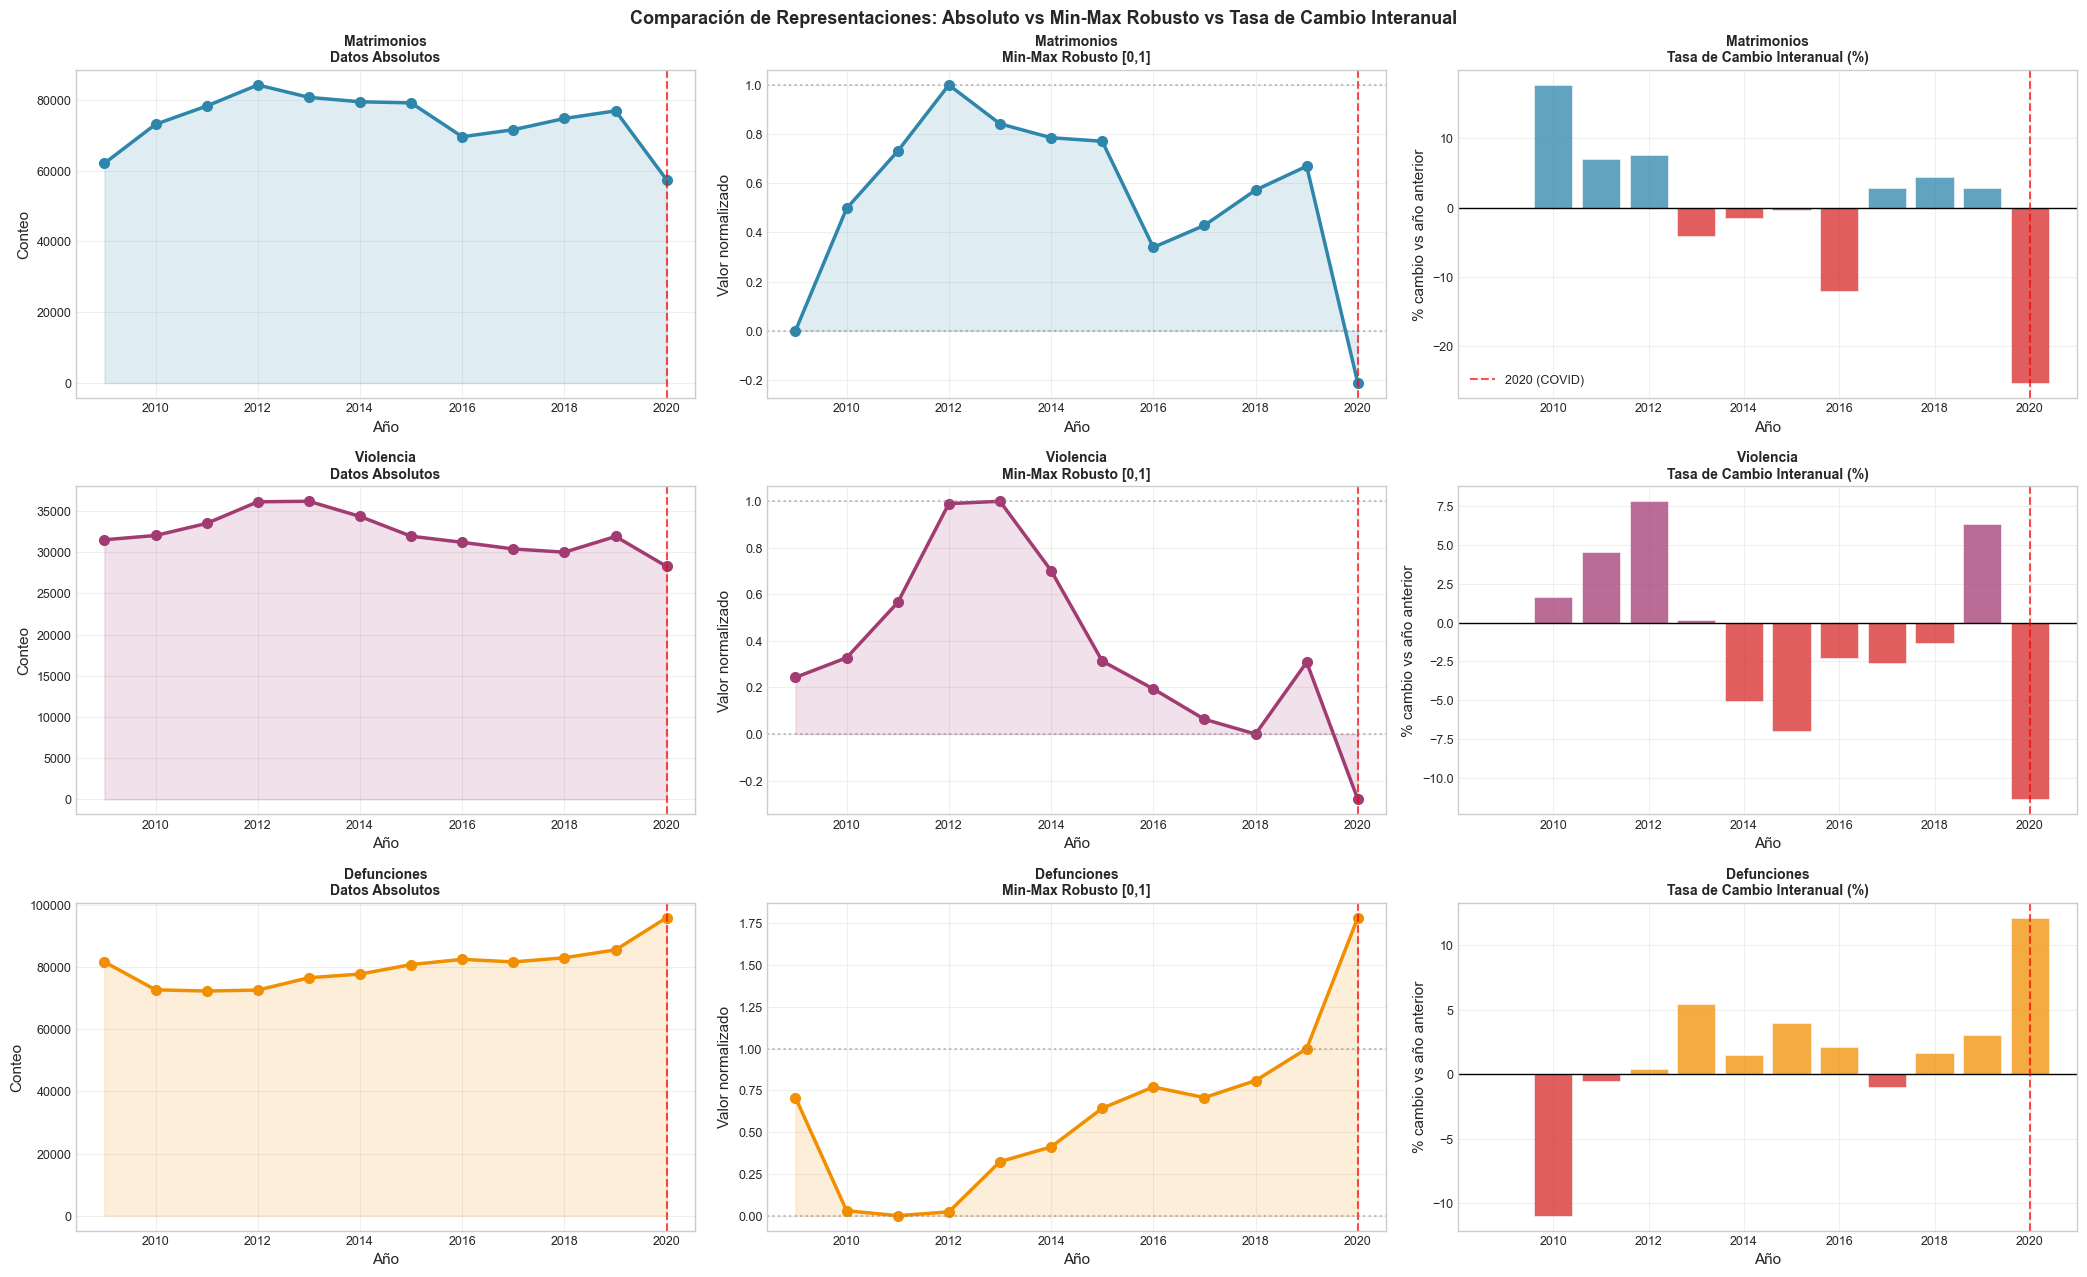


  OBSERVACIÓN CLAVE:
  ════════════════════════════════════════════════════════════════════
  Columna 1 (Absoluto) y Columna 2 (Min-Max) se VEN IGUAL → las
  proporciones relativas entre años no cambian con Min-Max.
  Columna 3 (Tasa %) revela la MAGNITUD del cambio año a año y hace
  que el impacto de 2020 sea visible en su contexto histórico.


In [61]:
fig, axes = plt.subplots(3, 3, figsize=(21, 13))
fig.suptitle('Comparación de Representaciones: Absoluto vs Min-Max Robusto vs Tasa de Cambio Interanual',
             fontsize=13, fontweight='bold')

series_info = [
    ('Matrimonios',  '#2E86AB'),
    ('Violencia',    '#A23B72'),
    ('Defunciones',  '#F18F01'),
]
años = df_tendencias['Año'].values

for row, (col, color) in enumerate(series_info):
    abs_vals  = df_tendencias[col].values
    mm_vals   = df_tendencias[col + '_MM'].values
    pct_vals  = df_tendencias[col + '_PctChange'].values

    # Absoluto
    axes[row,0].plot(años, abs_vals, marker='o', lw=2.5, ms=7, color=color)
    axes[row,0].fill_between(años, abs_vals, alpha=0.15, color=color)
    axes[row,0].axvline(2020, color='red', ls='--', lw=1.5, alpha=0.7)
    axes[row,0].set_title(f'{col}\nDatos Absolutos', fontsize=10, fontweight='bold')
    axes[row,0].set_ylabel('Conteo')
    axes[row,0].grid(True, alpha=0.3)

    # Min-Max Robusto
    axes[row,1].plot(años, mm_vals, marker='o', lw=2.5, ms=7, color=color)
    axes[row,1].fill_between(años, mm_vals, alpha=0.15, color=color)
    axes[row,1].axvline(2020, color='red', ls='--', lw=1.5, alpha=0.7)
    axes[row,1].axhline(1.0, color='gray', ls=':', alpha=0.5)
    axes[row,1].axhline(0.0, color='gray', ls=':', alpha=0.5)
    axes[row,1].set_title(f'{col}\nMin-Max Robusto [0,1]', fontsize=10, fontweight='bold')
    axes[row,1].set_ylabel('Valor normalizado')
    axes[row,1].grid(True, alpha=0.3)

    # Tasa de cambio interanual
    colores_barra = ['#D62828' if v < 0 else color for v in pct_vals]
    axes[row,2].bar(años, pct_vals, color=colores_barra, alpha=0.75, edgecolor='white', lw=0.5)
    axes[row,2].axhline(0, color='black', lw=1)
    axes[row,2].axvline(2020, color='red', ls='--', lw=1.5, alpha=0.7, label='2020 (COVID)')
    axes[row,2].set_title(f'{col}\nTasa de Cambio Interanual (%)', fontsize=10, fontweight='bold')
    axes[row,2].set_ylabel('% cambio vs año anterior')
    axes[row,2].grid(True, alpha=0.3)
    if row == 0:
        axes[row,2].legend(fontsize=9)

for ax in axes.flat:
    ax.set_xlabel('Año')
    ax.tick_params(labelsize=9)

plt.tight_layout()
plt.show()

print("\n  OBSERVACIÓN CLAVE:")
print("  ════════════════════════════════════════════════════════════════════")
print("  Columna 1 (Absoluto) y Columna 2 (Min-Max) se VEN IGUAL → las")
print("  proporciones relativas entre años no cambian con Min-Max.")
print("  Columna 3 (Tasa %) revela la MAGNITUD del cambio año a año y hace")
print("  que el impacto de 2020 sea visible en su contexto histórico.")


---
## HIPÓTESIS 1 — Tendencias Temporales con Datos Normalizados y Tasas de Cambio

**Supuesto:** La violencia intrafamiliar y las defunciones muestran tendencias correlacionadas.  
**Mejora respecto al caso base:** Se trabaja con tasas de variación interanual (% vs año anterior) y con Min-Max Robusto. Las correlaciones se calculan sobre las variaciones, no sobre los niveles absolutos.

HIPÓTESIS 1: TENDENCIAS TEMPORALES — SERIES NORMALIZADAS + TASAS DE CAMBIO


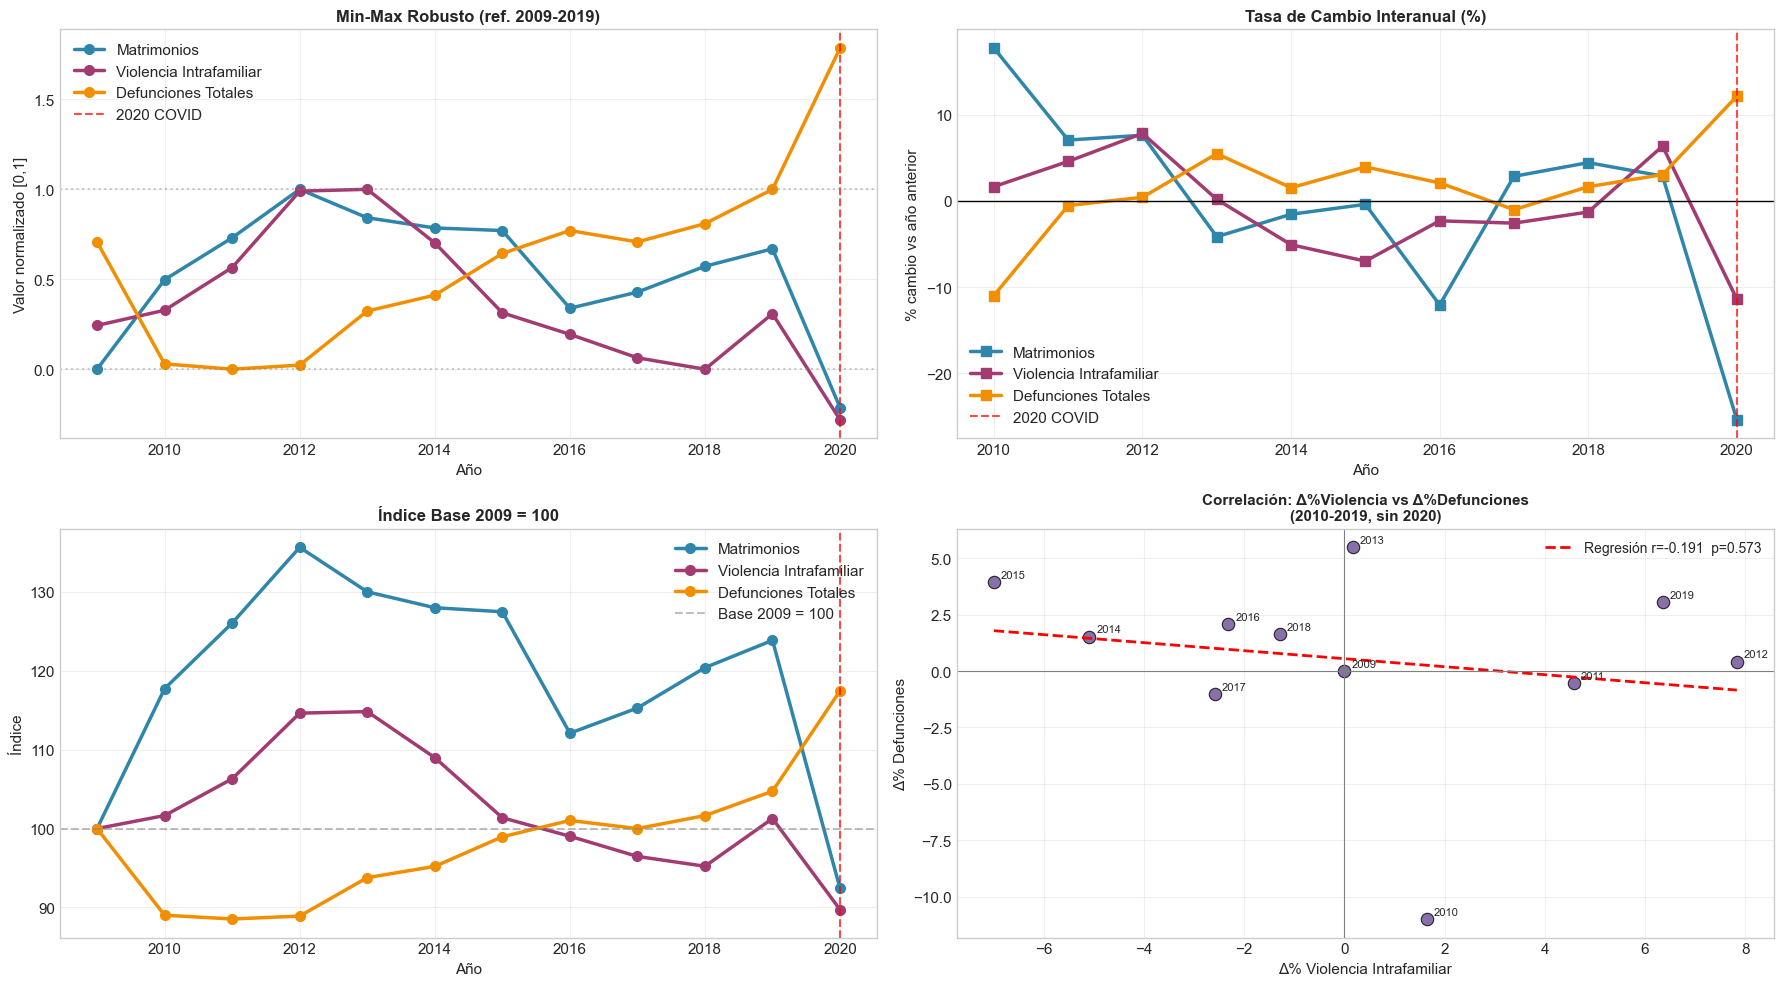


CORRELACIONES SOBRE TASAS DE CAMBIO INTERANUAL (2010-2019, sin 2020)
  Matrimonios                    × Violencia Intrafamiliar         Pearson r=+0.456  p=0.158   n.s.  Spearman ρ=+0.627
  Matrimonios                    × Defunciones Totales             Pearson r=-0.763  p=0.006 ✓ sig.  Spearman ρ=-0.627
  Violencia Intrafamiliar        × Defunciones Totales             Pearson r=-0.191  p=0.573   n.s.  Spearman ρ=-0.182

Cambio total 2009→2020: Matrimonios -7.6% | Violencia -10.3% | Defunciones +17.5%


In [62]:
print("="*80)
print("HIPÓTESIS 1: TENDENCIAS TEMPORALES — SERIES NORMALIZADAS + TASAS DE CAMBIO")
print("="*80)

años   = df_tendencias['Año'].values
COLS   = ['Matrimonios', 'Violencia', 'Defunciones']
COLORES= {'Matrimonios':'#2E86AB','Violencia':'#A23B72','Defunciones':'#F18F01'}
LABELS = {'Matrimonios':'Matrimonios','Violencia':'Violencia Intrafamiliar','Defunciones':'Defunciones Totales'}

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# ── Panel 1: Min-Max Robusto ──────────────────────────────────────────────────
for col in COLS:
    axes[0,0].plot(años, df_tendencias[col+'_MM'], marker='o', lw=2.5, ms=7,
                   color=COLORES[col], label=LABELS[col])
axes[0,0].axvline(2020, color='red', ls='--', lw=1.5, alpha=0.7, label='2020 COVID')
axes[0,0].axhline(0, color='gray', ls=':', alpha=0.4); axes[0,0].axhline(1, color='gray', ls=':', alpha=0.4)
axes[0,0].set_title('Min-Max Robusto (ref. 2009-2019)', fontsize=12, fontweight='bold')
axes[0,0].set_ylabel('Valor normalizado [0,1]'); axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

# ── Panel 2: Tasas de cambio interanual ───────────────────────────────────────
for col in COLS:
    axes[0,1].plot(años[1:], df_tendencias[col+'_PctChange'].values[1:],
                   marker='s', lw=2.5, ms=7, color=COLORES[col], label=LABELS[col])
axes[0,1].axhline(0, color='black', lw=1)
axes[0,1].axvline(2020, color='red', ls='--', lw=1.5, alpha=0.7, label='2020 COVID')
axes[0,1].set_title('Tasa de Cambio Interanual (%)', fontsize=12, fontweight='bold')
axes[0,1].set_ylabel('% cambio vs año anterior'); axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)

# ── Panel 3: Índice base 2009 = 100 ──────────────────────────────────────────
for col in COLS:
    axes[1,0].plot(años, df_tendencias[col+'_Idx'], marker='o', lw=2.5, ms=7,
                   color=COLORES[col], label=LABELS[col])
axes[1,0].axhline(100, color='gray', ls='--', alpha=0.5, label='Base 2009 = 100')
axes[1,0].axvline(2020, color='red', ls='--', lw=1.5, alpha=0.7)
axes[1,0].set_title('Índice Base 2009 = 100', fontsize=12, fontweight='bold')
axes[1,0].set_ylabel('Índice'); axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3)

# ── Panel 4: Scatter correlación violencia vs defunciones (por tasa) ──────────
vio_pct_sin2020 = df_tendencias.loc[df_tendencias['Año'] != 2020, 'Violencia_PctChange'].values
def_pct_sin2020 = df_tendencias.loc[df_tendencias['Año'] != 2020, 'Defunciones_PctChange'].values
años_sin2020    = df_tendencias.loc[df_tendencias['Año'] != 2020, 'Año'].values

axes[1,1].scatter(vio_pct_sin2020, def_pct_sin2020, s=80, color='#6A4C93', alpha=0.8, edgecolors='black', lw=0.8)
for a, vx, dy in zip(años_sin2020, vio_pct_sin2020, def_pct_sin2020):
    axes[1,1].annotate(str(a), (vx, dy), fontsize=8, textcoords='offset points', xytext=(5,3))
m, b, r, p, _ = stats.linregress(vio_pct_sin2020, def_pct_sin2020)
xr = np.linspace(vio_pct_sin2020.min(), vio_pct_sin2020.max(), 50)
axes[1,1].plot(xr, m*xr+b, 'r--', lw=2, label=f'Regresión r={r:.3f}  p={p:.3f}')
axes[1,1].axhline(0, color='gray', lw=0.8); axes[1,1].axvline(0, color='gray', lw=0.8)
axes[1,1].set_title('Correlación: Δ%Violencia vs Δ%Defunciones\n(2010-2019, sin 2020)',
                     fontsize=11, fontweight='bold')
axes[1,1].set_xlabel('Δ% Violencia Intrafamiliar'); axes[1,1].set_ylabel('Δ% Defunciones')
axes[1,1].legend(fontsize=10); axes[1,1].grid(True, alpha=0.3)

for ax in axes.flat:
    ax.set_xlabel('Año' if ax != axes[1,1] else ax.get_xlabel())

plt.tight_layout()
plt.show()

# ── Estadísticos ──────────────────────────────────────────────────────────────
print("\n" + "="*70)
print("CORRELACIONES SOBRE TASAS DE CAMBIO INTERANUAL (2010-2019, sin 2020)")
print("="*70)
for col_a, col_b in [('Matrimonios','Violencia'),('Matrimonios','Defunciones'),('Violencia','Defunciones')]:
    a_v = df_tendencias.loc[df_tendencias['Año']!=2020, col_a+'_PctChange'].values
    b_v = df_tendencias.loc[df_tendencias['Año']!=2020, col_b+'_PctChange'].values
    r, p = pearsonr(a_v, b_v)
    rs, ps = spearmanr(a_v, b_v)
    sig = "✓ sig." if p < 0.05 else "  n.s."
    print(f"  {LABELS[col_a]:30s} × {LABELS[col_b]:30s}  Pearson r={r:+.3f}  p={p:.3f} {sig}  Spearman ρ={rs:+.3f}")

cambio_mat = ((matrimonios_anual[2020] - matrimonios_anual[2009]) / matrimonios_anual[2009] * 100)
cambio_vio = ((violencia_anual[2020]   - violencia_anual[2009])   / violencia_anual[2009]   * 100)
cambio_def = ((defunciones_anual[2020] - defunciones_anual[2009]) / defunciones_anual[2009] * 100)
print(f"\nCambio total 2009→2020: Matrimonios {cambio_mat:+.1f}% | Violencia {cambio_vio:+.1f}% | Defunciones {cambio_def:+.1f}%")


---
## HIPÓTESIS 2 — Patrones Geográficos con Tasas Porcentuales por Departamento

**Supuesto:** La violencia se concentra en departamentos urbanos.  
**Mejora respecto al caso base:** En lugar de conteos absolutos (que siempre dominan Guatemala capital), se usa la **participación porcentual de cada departamento en el total nacional** de cada año. Así, un departamento pequeño pero con alta proporción de casos es visible.

HIPÓTESIS 2: PATRONES GEOGRÁFICOS — PARTICIPACIÓN PORCENTUAL INTRA-AÑO

Ranking por CONTEO ABSOLUTO (2009-2020 acumulado):
Rank  Defunciones                Violencia                
   1.  Guatemala                  Guatemala                
   2.  Alta Verapaz               Alta Verapaz             
   3.  Quetzaltenango             Suchitepéquez            
   4.  San Marcos                 San Marcos               
   5.  Escuintla                  Chimaltenango            
   6.  Huehuetenango              Quetzaltenango           
   7.  Quiché                     Sacatepéquez             
   8.  Suchitepéquez              Retalhuleu               
   9.  Chimaltenango              Huehuetenango            
  10.  Jutiapa                    Santa Rosa               

Ranking por % PROMEDIO INTRA-AÑO (ref. 2009-2019):
Rank  Defunciones %                   Violencia %                   
   1.  Guatemala                 29.41%   Guatemala                 18.72%
   2.  Alta Verapaz   

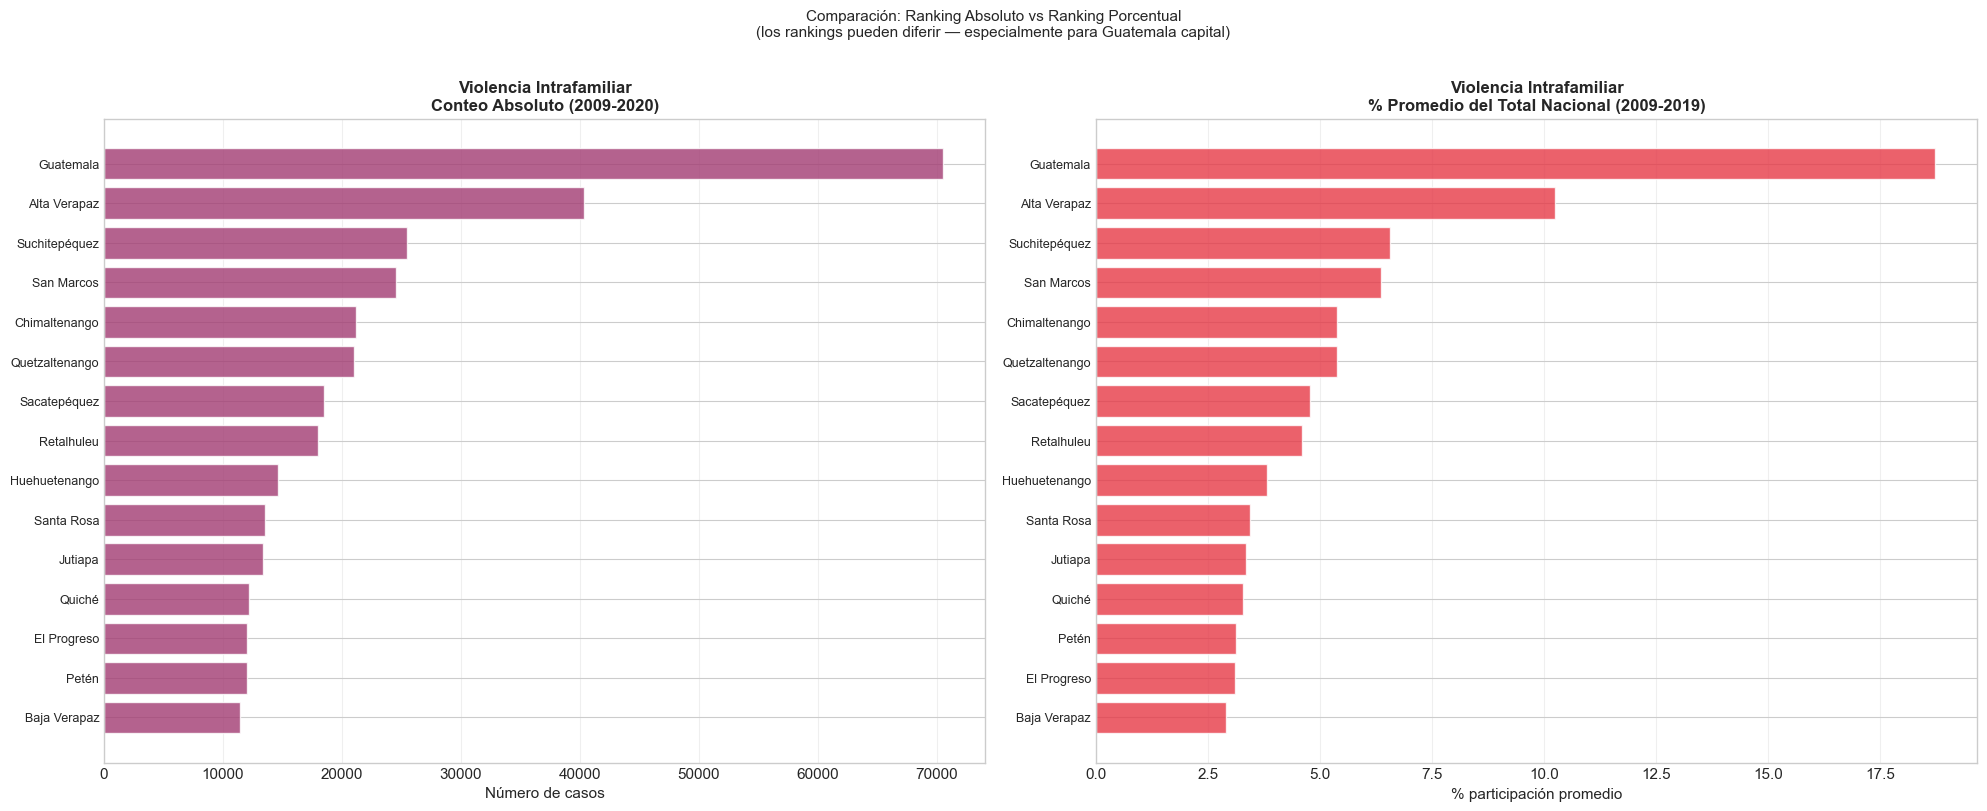

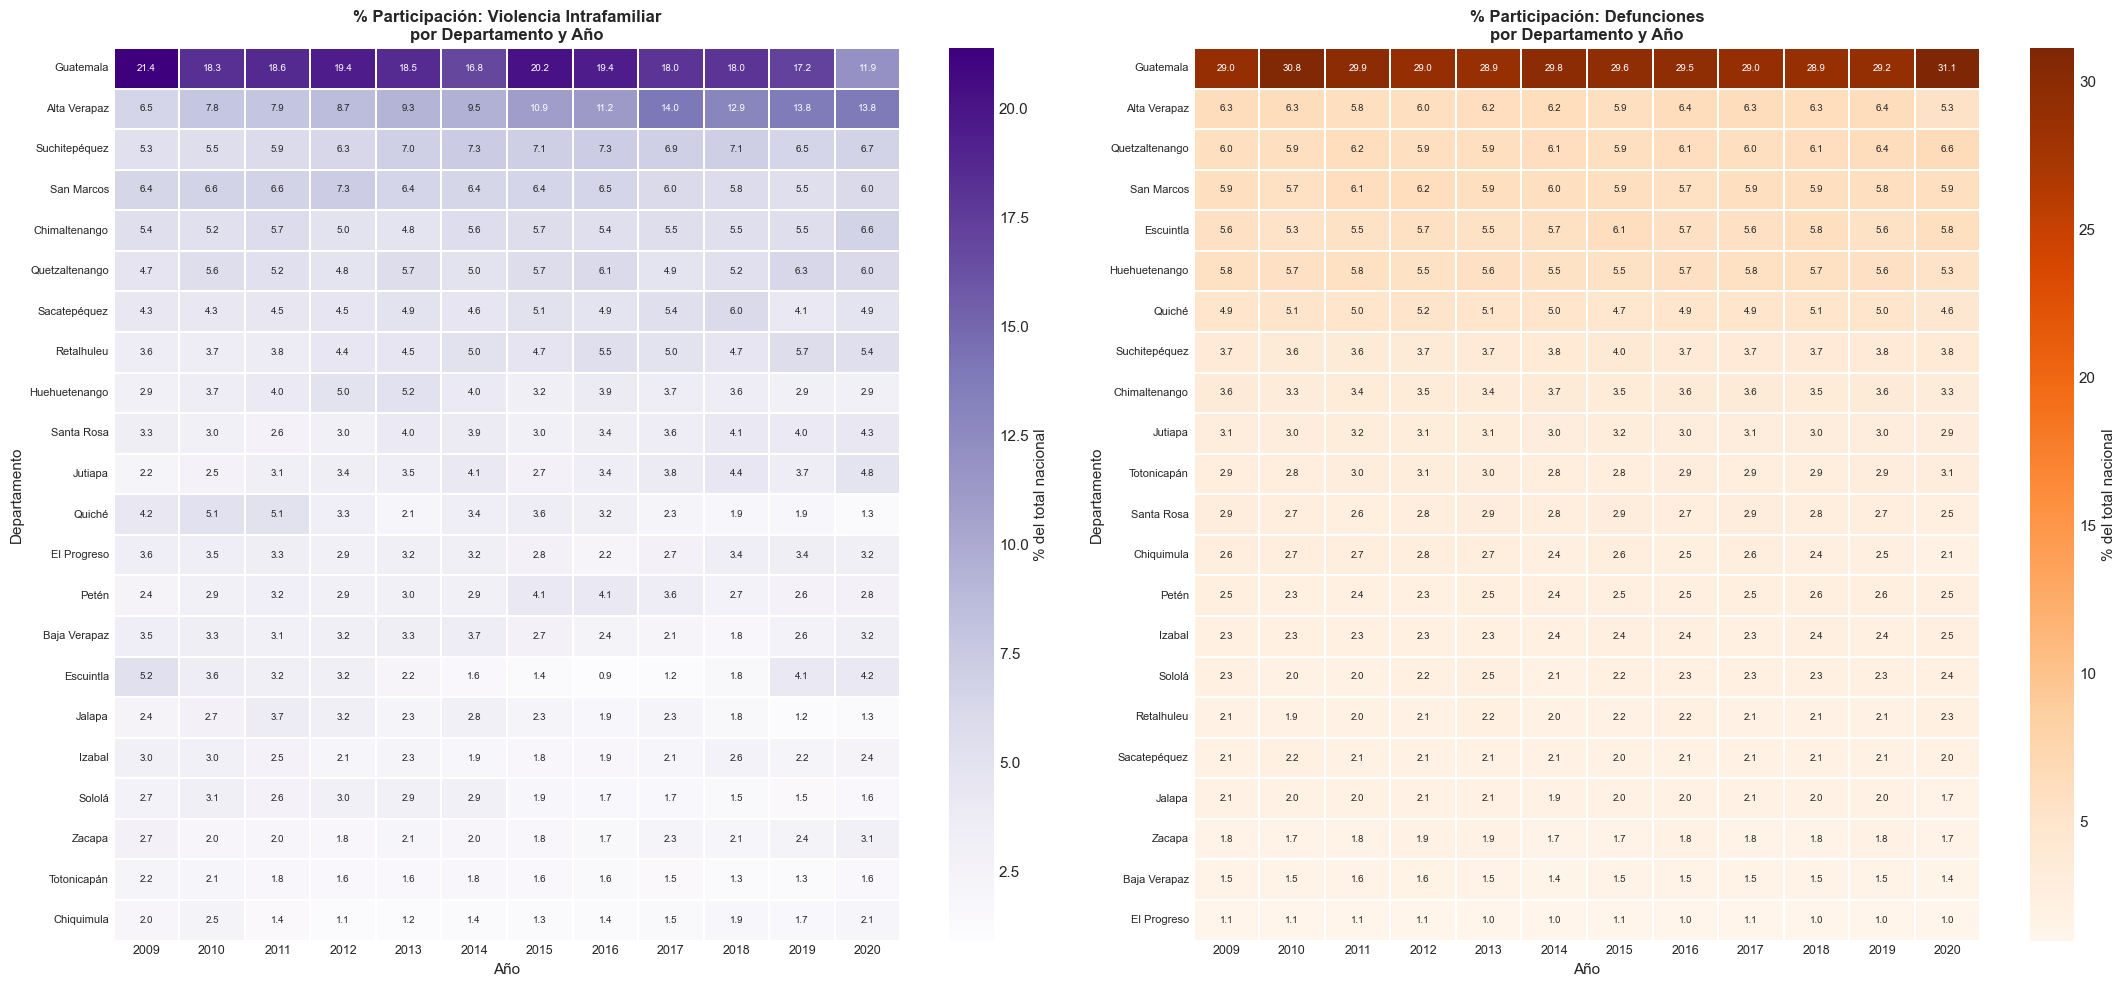


  CONCLUSIÓN HIPÓTESIS 2:
  El heatmap de % muestra la INTENSIDAD RELATIVA de cada departamento cada año.
  Departamentos pequeños que en conteo absoluto son invisibles aquí son
  detectables si su % de participación aumenta en años específicos.


In [63]:
print("="*80)
print("HIPÓTESIS 2: PATRONES GEOGRÁFICOS — PARTICIPACIÓN PORCENTUAL INTRA-AÑO")
print("="*80)

# ── Tabla comparativa: ranking por conteo absoluto vs ranking por % ─────────────
abs_def = df_defunciones.groupby('Departamento').size().sort_values(ascending=False).head(15)
abs_vio = df_violencia.groupby('Departamento').size().sort_values(ascending=False).head(15)

print("\nRanking por CONTEO ABSOLUTO (2009-2020 acumulado):")
print(f"{'Rank':>4}  {'Defunciones':25}  {'Violencia':25}")
for i, (d, v) in enumerate(zip(abs_def.index[:10], abs_vio.index[:10]), 1):
    print(f"  {i:>2}.  {d:25}  {v:25}")

print("\nRanking por % PROMEDIO INTRA-AÑO (ref. 2009-2019):")
print(f"{'Rank':>4}  {'Defunciones %':30}  {'Violencia %':30}")
for i, ((d, pv), (v, pvi)) in enumerate(zip(pct_prom_def.head(10).items(), pct_prom_vio.head(10).items()), 1):
    print(f"  {i:>2}.  {d:25} {pv:5.2f}%   {v:25} {pvi:5.2f}%")

# ── Visualización 1: Barras comparativas — conteo absoluto vs tasa % ───────────
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
top_n = 15

# Panel izquierdo: conteo absoluto acumulado
n_abs_vio = df_violencia.groupby('Departamento').size().sort_values(ascending=False).head(top_n)
axes[0].barh(range(len(n_abs_vio)), n_abs_vio.values[::-1], color='#A23B72', alpha=0.8, edgecolor='white')
axes[0].set_yticks(range(len(n_abs_vio)))
axes[0].set_yticklabels(n_abs_vio.index[::-1], fontsize=9)
axes[0].set_title('Violencia Intrafamiliar\nConteo Absoluto (2009-2020)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Número de casos'); axes[0].grid(axis='x', alpha=0.3)

# Panel derecho: participación % promedio (2009-2019)
top_pct = pct_prom_vio.head(top_n)
axes[1].barh(range(len(top_pct)), top_pct.values[::-1], color='#E63946', alpha=0.8, edgecolor='white')
axes[1].set_yticks(range(len(top_pct)))
axes[1].set_yticklabels(top_pct.index[::-1], fontsize=9)
axes[1].set_title('Violencia Intrafamiliar\n% Promedio del Total Nacional (2009-2019)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('% participación promedio'); axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Comparación: Ranking Absoluto vs Ranking Porcentual\n(los rankings pueden diferir — especialmente para Guatemala capital)',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

# ── Visualización 2: Heatmap departamento × año (% intra-año) ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(22, 10))

for ax, (pct_src, titulo, cmap) in zip(axes, [
        (pct_vio,  'Violencia Intrafamiliar', 'Purples'),
        (pct_def,  'Defunciones',             'Oranges'),
    ]):
    pivot = (pct_src.pivot_table(index='Departamento', columns='ANIO',
                                 values='PctNacional', aggfunc='mean')
                    .fillna(0))
    pivot = pivot.dropna(how='all')          # quitar filas vacías
    pivot = pivot.loc[:, (pivot != 0).any()] # quitar columnas vacías
    sorted_idx = pivot.mean(axis=1).sort_values(ascending=False).dropna().index
    pivot = pivot.loc[sorted_idx]
    if pivot.empty:
        ax.set_title(f'{titulo} — sin datos'); continue
    sns.heatmap(pivot, ax=ax, cmap=cmap, annot=True, fmt='.1f',
                annot_kws={'size':7}, linewidths=0.3, cbar_kws={'label':'% del total nacional'})
    ax.set_title(f'% Participación: {titulo}\npor Departamento y Año', fontsize=12, fontweight='bold')
    ax.set_xlabel('Año'); ax.set_ylabel('Departamento')
    ax.tick_params(axis='x', labelsize=9); ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()

print("\n  CONCLUSIÓN HIPÓTESIS 2:")
print("  El heatmap de % muestra la INTENSIDAD RELATIVA de cada departamento cada año.")
print("  Departamentos pequeños que en conteo absoluto son invisibles aquí son")
print("  detectables si su % de participación aumenta en años específicos.")


---
## HIPÓTESIS 3 — Edad y Vulnerabilidad con Índice de Sobrerepresentación

**Supuesto:** Mujeres jóvenes de 18-30 años son las más vulnerables.  
**Mejora:** En lugar de conteos crudos, se calcula el **índice de sobrerepresentación** = % del grupo en violencia / % del mismo grupo en matrimonios (proxy de población). Un índice > 1 indica que ese grupo está más afectado de lo que su peso poblacional esperaría.

HIPÓTESIS 3: EDAD Y VULNERABILIDAD — ÍNDICE DE SOBREREPRESENTACIÓN
Distribución de edad en violencia por sexo (%):
           Sexo_1  Sexo_2
GrupoEdad                
<18        4.4200  4.4200
18-25     16.1800 29.1400
26-35     27.3200 34.8500
36-45     19.9900 18.6400
46-55     12.5300  7.1700
>55       19.5600  5.7700

Distribución de edad en matrimonios — referencia poblacional (%)
GrupoEdad
<18      1.3300
18-25   46.4000
26-35   33.5800
36-45    9.6400
46-55    4.2200
>55      4.8300
Name: proportion, dtype: float64


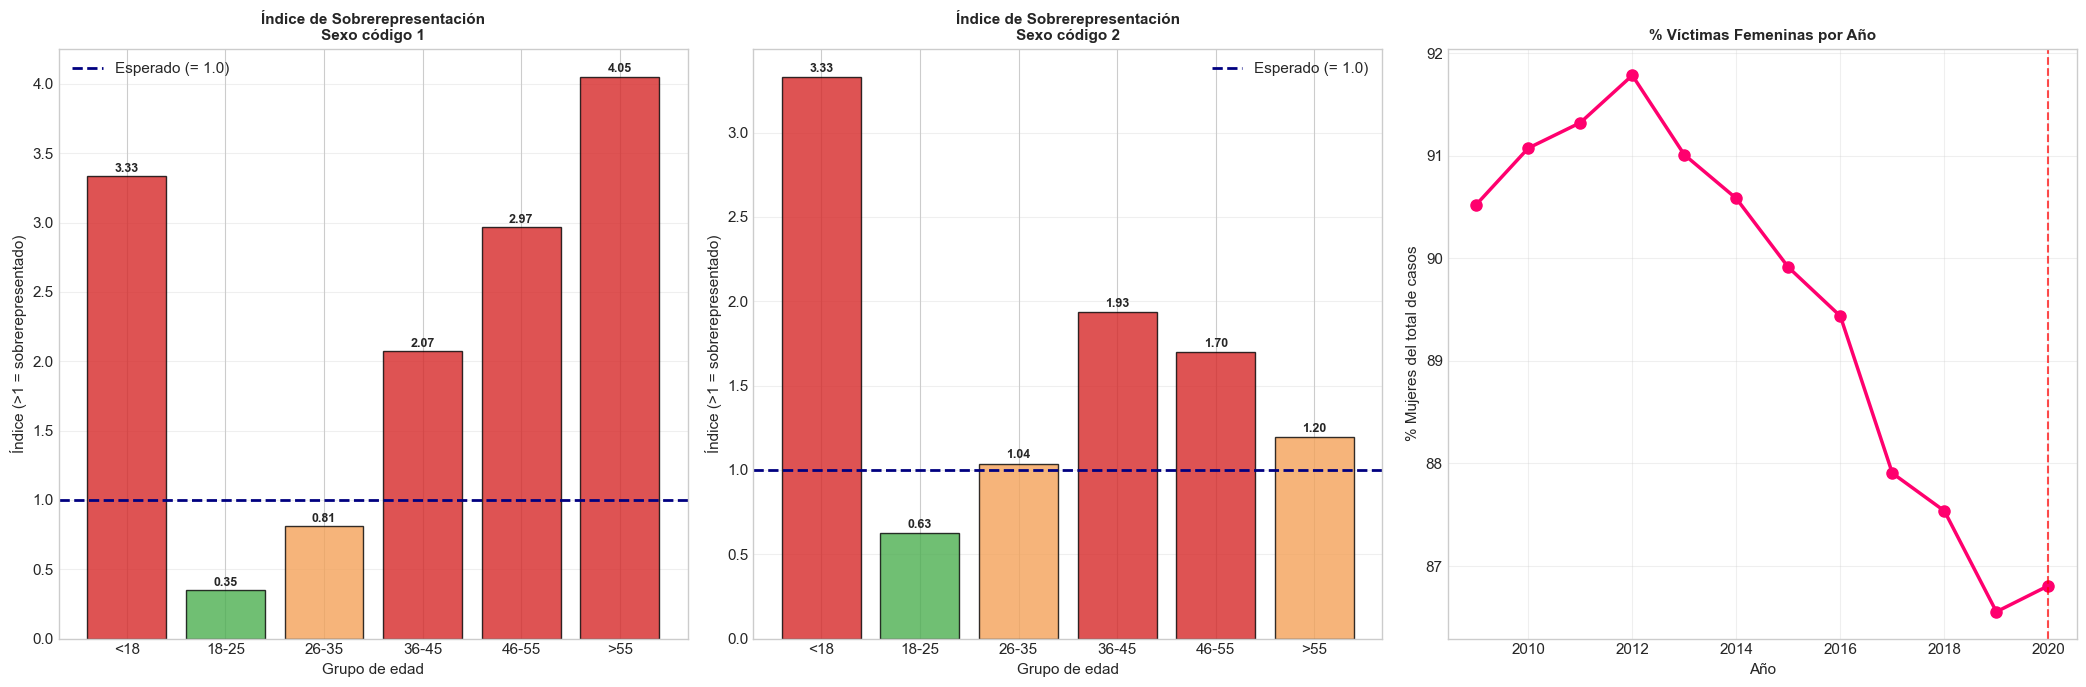

In [64]:
print("="*80)
print("HIPÓTESIS 3: EDAD Y VULNERABILIDAD — ÍNDICE DE SOBREREPRESENTACIÓN")
print("="*80)

BINS_EDAD = [0, 17, 25, 35, 45, 55, 120]
LABS_EDAD = ['<18', '18-25', '26-35', '36-45', '46-55', '>55']

def col_edad(df, kw='EDAD'):
    for c in df.columns:
        if kw in c.upper(): return c
    return None

def col_sexo(df, kw='SEXO'):
    for c in df.columns:
        if kw in c.upper(): return c
    return None

edad_vio = col_edad(df_violencia)
sexo_vio = col_sexo(df_violencia)
edad_mat = col_edad(df_matrimonios)

if edad_vio and sexo_vio:
    df_violencia['GrupoEdad'] = pd.cut(df_violencia[edad_vio], bins=BINS_EDAD, labels=LABS_EDAD)
    dist_vio_sexo = pd.crosstab(df_violencia['GrupoEdad'], df_violencia[sexo_vio], normalize='columns') * 100
    dist_vio_sexo.columns = [f'Sexo_{int(c)}' for c in dist_vio_sexo.columns]
    print("Distribución de edad en violencia por sexo (%):")
    print(dist_vio_sexo.round(2))

if edad_mat:
    # Usar primera col edad como proxy de distribución etaria "de referencia"
    edad_ref_col = col_edad(df_matrimonios)
    df_matrimonios['GrupoEdad'] = pd.cut(df_matrimonios[edad_ref_col], bins=BINS_EDAD, labels=LABS_EDAD)
    dist_mat_ref = (df_matrimonios['GrupoEdad'].value_counts(normalize=True).sort_index() * 100)
    print(f"\nDistribución de edad en matrimonios — referencia poblacional (%)")
    print(dist_mat_ref.round(2))

if edad_vio and sexo_vio and edad_mat:
    sexo_vals = sorted(df_violencia[sexo_vio].dropna().unique())
    fig, axes = plt.subplots(1, len(sexo_vals) + 1, figsize=(7 * (len(sexo_vals) + 1), 7))

    for idx_s, sv in enumerate(sexo_vals):
        subset = df_violencia[df_violencia[sexo_vio] == sv]
        dist_s = (subset['GrupoEdad'].value_counts(normalize=True).sort_index() * 100)
        indice = (dist_s / dist_mat_ref).replace([np.inf], np.nan).fillna(0)

        col_bar = ['#D62828' if v > 1.2 else '#4CAF50' if v < 0.8 else '#F4A259'
                   for v in indice.values]
        axes[idx_s].bar(LABS_EDAD, indice.values, color=col_bar, alpha=0.8, edgecolor='black')
        axes[idx_s].axhline(1.0, color='navy', ls='--', lw=2, label='Esperado (= 1.0)')
        axes[idx_s].set_title(f'Índice de Sobrerepresentación\nSexo código {int(sv)}', fontsize=11, fontweight='bold')
        axes[idx_s].set_ylabel('Índice (>1 = sobrerepresentado)'); axes[idx_s].set_xlabel('Grupo de edad')
        axes[idx_s].legend(); axes[idx_s].grid(axis='y', alpha=0.3)
        for i, (lab, val) in enumerate(zip(LABS_EDAD, indice.values)):
            axes[idx_s].text(i, val + 0.03, f'{val:.2f}', ha='center', fontsize=9, fontweight='bold')

    # Panel final: evolución % mujeres víctimas por año
    ax_evo = axes[-1]
    vio_anual_sexo = df_violencia.groupby(['ANIO', sexo_vio]).size().unstack(fill_value=0)
    if 2 in vio_anual_sexo.columns:
        pct_fem = (vio_anual_sexo[2] / vio_anual_sexo.sum(axis=1) * 100)
        ax_evo.plot(pct_fem.index, pct_fem.values, marker='o', lw=2.5, ms=8, color='#FF006E')
        ax_evo.axvline(2020, color='red', ls='--', lw=1.5, alpha=0.7)
        ax_evo.set_title('% Víctimas Femeninas por Año', fontsize=11, fontweight='bold')
        ax_evo.set_ylabel('% Mujeres del total de casos'); ax_evo.set_xlabel('Año')
        ax_evo.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("  No se encontraron las columnas necesarias para este análisis.")


---
## HIPÓTESIS 4 — Estacionalidad con Índice Mensual Porcentual

**Supuesto:** Existen picos estacionales en épocas festivas (diciembre/enero).  
**Mejora:** Se usa el **índice estacional mensual** = (casos del mes / promedio mensual esperado) × 100. Un valor > 100 indica un mes con más casos de lo históricamente esperado en promedio. Esto elimina el efecto de que los años más recientes tienen más datos en términos absolutos.

HIPÓTESIS 4: ESTACIONALIDAD — ÍNDICE MENSUAL PORCENTUAL


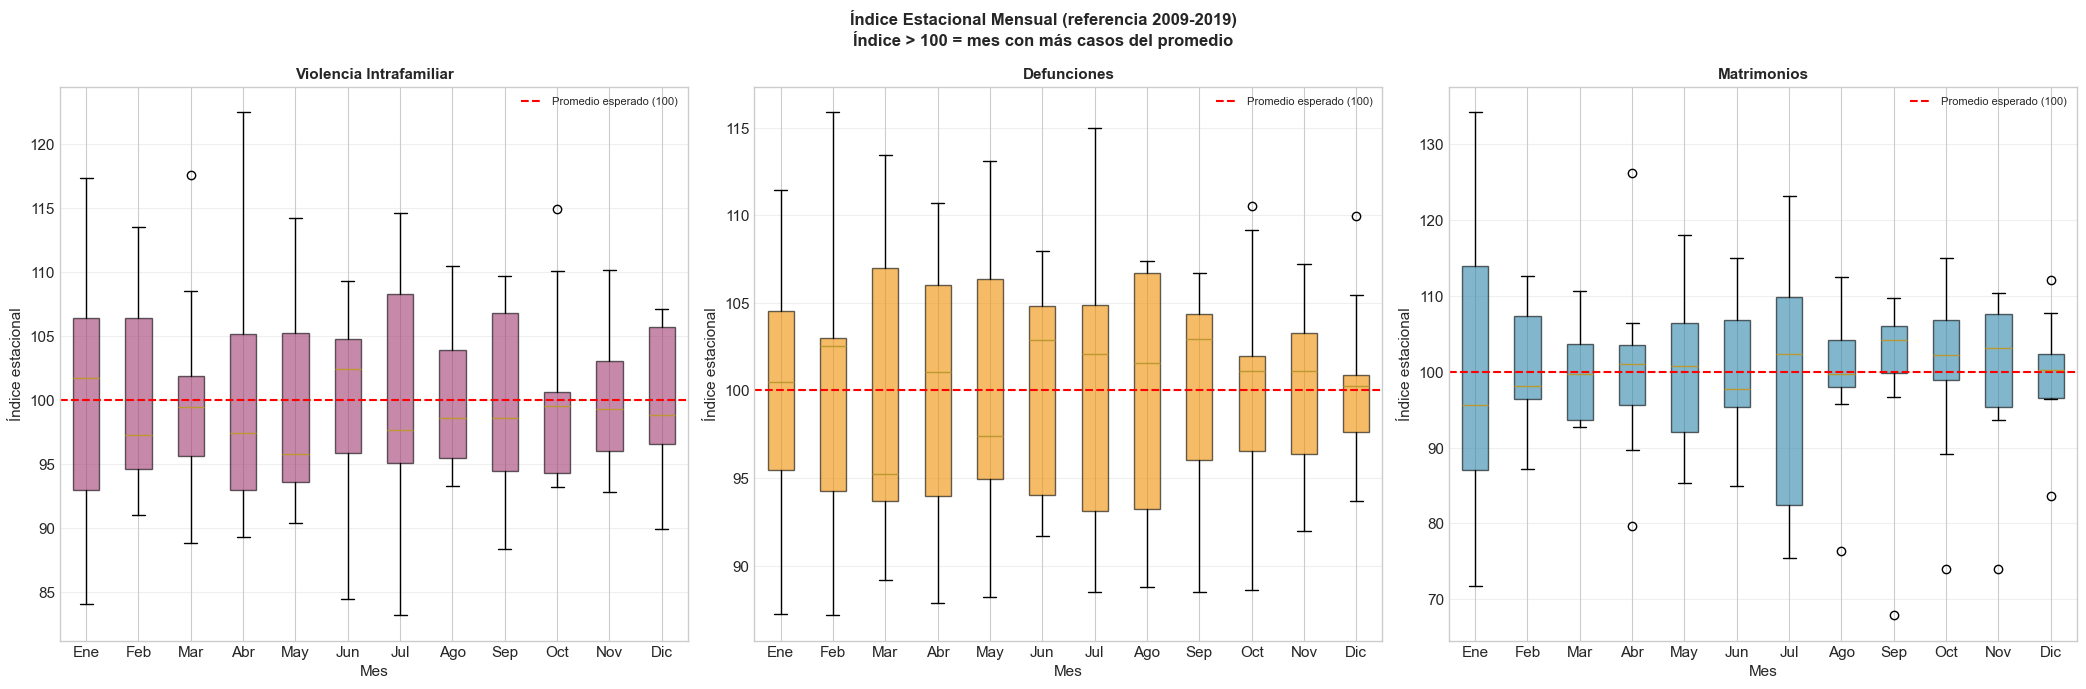


TEST CHI-CUADRADO: ¿Distribución mensual uniforme?
  Violencia Intrafamiliar         χ²=1516.07  p=0.0000  ✓ ESTACIONALIDAD SIGNIFICATIVA
  Defunciones                     χ²=1724.28  p=0.0000  ✓ ESTACIONALIDAD SIGNIFICATIVA
  Matrimonios                     χ²=7423.03  p=0.0000  ✓ ESTACIONALIDAD SIGNIFICATIVA


In [65]:
print("="*80)
print("HIPÓTESIS 4: ESTACIONALIDAD — ÍNDICE MENSUAL PORCENTUAL")
print("="*80)

MESES_NOMBRES = {1:'Ene',2:'Feb',3:'Mar',4:'Abr',5:'May',6:'Jun',
                 7:'Jul',8:'Ago',9:'Sep',10:'Oct',11:'Nov',12:'Dic'}

def col_mes(df, kw='MES'):
    for c in df.columns:
        if kw in c.upper(): return c
    return None

def indice_estacional(df, col_anio='ANIO', col_mes_kw='MES', excluir_año=2020):
    """
    Calcula el índice estacional mensual por año (excluyendo año outlier de referencia).
    Índice = (casos_mes_año / promedio_mensual_histórico_ese_mes) × 100
    """
    mc = col_mes(df, col_mes_kw)
    if not mc:
        return None, None
    conteo = df.groupby([col_anio, mc]).size().reset_index(name='Casos')
    ref = conteo[conteo[col_anio] != excluir_año]
    prom_mes = ref.groupby(mc)['Casos'].mean()

    conteo['Indice'] = conteo.apply(
        lambda r: (r['Casos'] / prom_mes.get(r[mc], np.nan)) * 100
        if prom_mes.get(r[mc], 0) > 0 else np.nan, axis=1)
    return conteo, mc

idx_vio, mc_vio = indice_estacional(df_violencia)
idx_def, mc_def = indice_estacional(df_defunciones)
idx_mat, mc_mat = indice_estacional(df_matrimonios)

datasets_estac = [
    (idx_vio, mc_vio, 'Violencia Intrafamiliar', '#A23B72'),
    (idx_def, mc_def, 'Defunciones',             '#F18F01'),
    (idx_mat, mc_mat, 'Matrimonios',              '#2E86AB'),
]

# ── Gráfico 1: Boxplot del índice por mes (promedio histórico 2009-2019) ──────
fig, axes = plt.subplots(1, 3, figsize=(21, 7))
fig.suptitle('Índice Estacional Mensual (referencia 2009-2019)\nÍndice > 100 = mes con más casos del promedio',
             fontsize=12, fontweight='bold')

for ax, (idx_df, mc, titulo, color) in zip(axes, datasets_estac):
    if idx_df is None:
        ax.text(0.5, 0.5, 'Sin columna de mes', ha='center', transform=ax.transAxes)
        continue
    ref = idx_df[idx_df['ANIO'] != 2020]
    mes_vals = [ref[ref[mc] == m]['Indice'].values for m in range(1, 13)]
    bp = ax.boxplot(mes_vals, labels=[MESES_NOMBRES.get(m, m) for m in range(1, 13)],
                    patch_artist=True, boxprops=dict(facecolor=color, alpha=0.6))
    ax.axhline(100, color='red', ls='--', lw=1.5, label='Promedio esperado (100)')
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.set_ylabel('Índice estacional'); ax.set_xlabel('Mes')
    ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ── Test Chi-cuadrado de uniformidad mensual ──────────────────────────────────
print("\n" + "="*60)
print("TEST CHI-CUADRADO: ¿Distribución mensual uniforme?")
print("="*60)
for idx_df, mc, titulo, _ in datasets_estac:
    if idx_df is None:
        continue
    ref = idx_df[(idx_df['ANIO'] != 2020)]
    freq_mes = ref.groupby(mc)['Casos'].sum().reindex(range(1, 13), fill_value=0)
    chi2, p = stats.chisquare(freq_mes.values)
    sig = "✓ ESTACIONALIDAD SIGNIFICATIVA" if p < 0.05 else "  no significativo"
    print(f"  {titulo:30s}  χ²={chi2:.2f}  p={p:.4f}  {sig}")


---
## HIPÓTESIS 5 — Educación como Factor Protector: Razón de Prevalencia

**Supuesto:** Menor educación → mayor riesgo de violencia.  
**Mejora:** Se calcula la **razón de prevalencia** = % de ese nivel educativo en violencia / % del mismo nivel en matrimonios. Valores > 1.5 indican riesgo elevado; valores < 0.7 indican efecto protector del nivel educativo.

In [66]:
print("="*80)
print("HIPÓTESIS 5: EDUCACIÓN — RAZÓN DE PREVALENCIA vs MATRIMONIOS")
print("="*80)

def col_educ(df, kw='EDUC'):
    for c in df.columns:
        if kw in c.upper(): return c
    return None

educ_vio = col_educ(df_violencia)
educ_mat = col_educ(df_matrimonios)

if educ_vio and educ_mat:
    # Distribuciones porcentuales
    dist_vio_educ = (df_violencia[educ_vio].value_counts(normalize=True).sort_index() * 100)
    dist_mat_educ = (df_matrimonios[educ_mat].value_counts(normalize=True).sort_index() * 100)

    # Alinear índices
    idx_comun = sorted(set(dist_vio_educ.index) & set(dist_mat_educ.index))
    dv = dist_vio_educ.reindex(idx_comun).fillna(0)
    dm = dist_mat_educ.reindex(idx_comun).fillna(0)

    # Razón de prevalencia
    razon = (dv / dm.replace(0, np.nan)).fillna(0)

    df_educ_comp = pd.DataFrame({
        '% en Violencia': dv,
        '% en Matrimonios (ref)': dm,
        'Razón de Prevalencia': razon
    }).sort_values('Razón de Prevalencia', ascending=False)

    print("\nPerfil educativo comparado:")
    print(df_educ_comp.round(3).to_string())

    # Test chi-cuadrado
    chi2, p, dof, _ = chi2_contingency(
        pd.crosstab(df_violencia[educ_vio].dropna(),
                    pd.Series(['violencia'] * len(df_violencia[educ_vio].dropna())))
    )
    print(f"\nTest χ² educación (violencia):  p = {p:.4f}")

    # Visualización
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # Barras divergentes: % diferencia entre violencia y matrimonios
    diferencia = (dv - dm).sort_values(ascending=False)
    colores_d = ['#D62828' if v > 0 else '#2B9348' for v in diferencia.values]
    axes[0].barh(range(len(diferencia)), diferencia.values, color=colores_d, alpha=0.8, edgecolor='white')
    axes[0].axvline(0, color='black', lw=1)
    axes[0].set_yticks(range(len(diferencia)))
    axes[0].set_yticklabels([str(i) for i in diferencia.index], fontsize=9)
    axes[0].set_title('Diferencia (% Violencia) − (% Matrimonios)\nRojo = sobrerepresentado en violencia',
                       fontsize=11, fontweight='bold')
    axes[0].set_xlabel('Diferencia porcentual'); axes[0].grid(axis='x', alpha=0.3)

    # Razón de prevalencia
    colores_r = ['#D62828' if v > 1.5 else '#F4A259' if v > 1.0 else '#2B9348'
                 for v in razon.values]
    axes[1].barh(range(len(razon)), razon.values, color=colores_r, alpha=0.8, edgecolor='white')
    axes[1].axvline(1.0, color='navy', ls='--', lw=2, label='Razón = 1 (sin diferencia)')
    axes[1].axvline(1.5, color='red',  ls=':',  lw=1.5, label='Umbral de riesgo (1.5)')
    axes[1].set_yticks(range(len(razon)))
    axes[1].set_yticklabels([str(i) for i in razon.index], fontsize=9)
    axes[1].set_title('Razón de Prevalencia por Nivel Educativo\n(>1.5 = posible factor de riesgo)',
                       fontsize=11, fontweight='bold')
    axes[1].set_xlabel('Razón de prevalencia'); axes[1].legend(fontsize=9); axes[1].grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("  No se encontraron columnas de educación en los datasets.")


HIPÓTESIS 5: EDUCACIÓN — RAZÓN DE PREVALENCIA vs MATRIMONIOS
  No se encontraron columnas de educación en los datasets.


---
# INCISO E — Análisis Exploratorio con Métricas Normalizadas

## E.1 — Heatmap de Completitud Porcentual por Variable y Año

Muestra el % de valores no nulos por variable × año para detectar si la pérdida de datos se concentra en años específicos (como 2020).

E.1 — HEATMAP DE COMPLETITUD PORCENTUAL (variables × años)


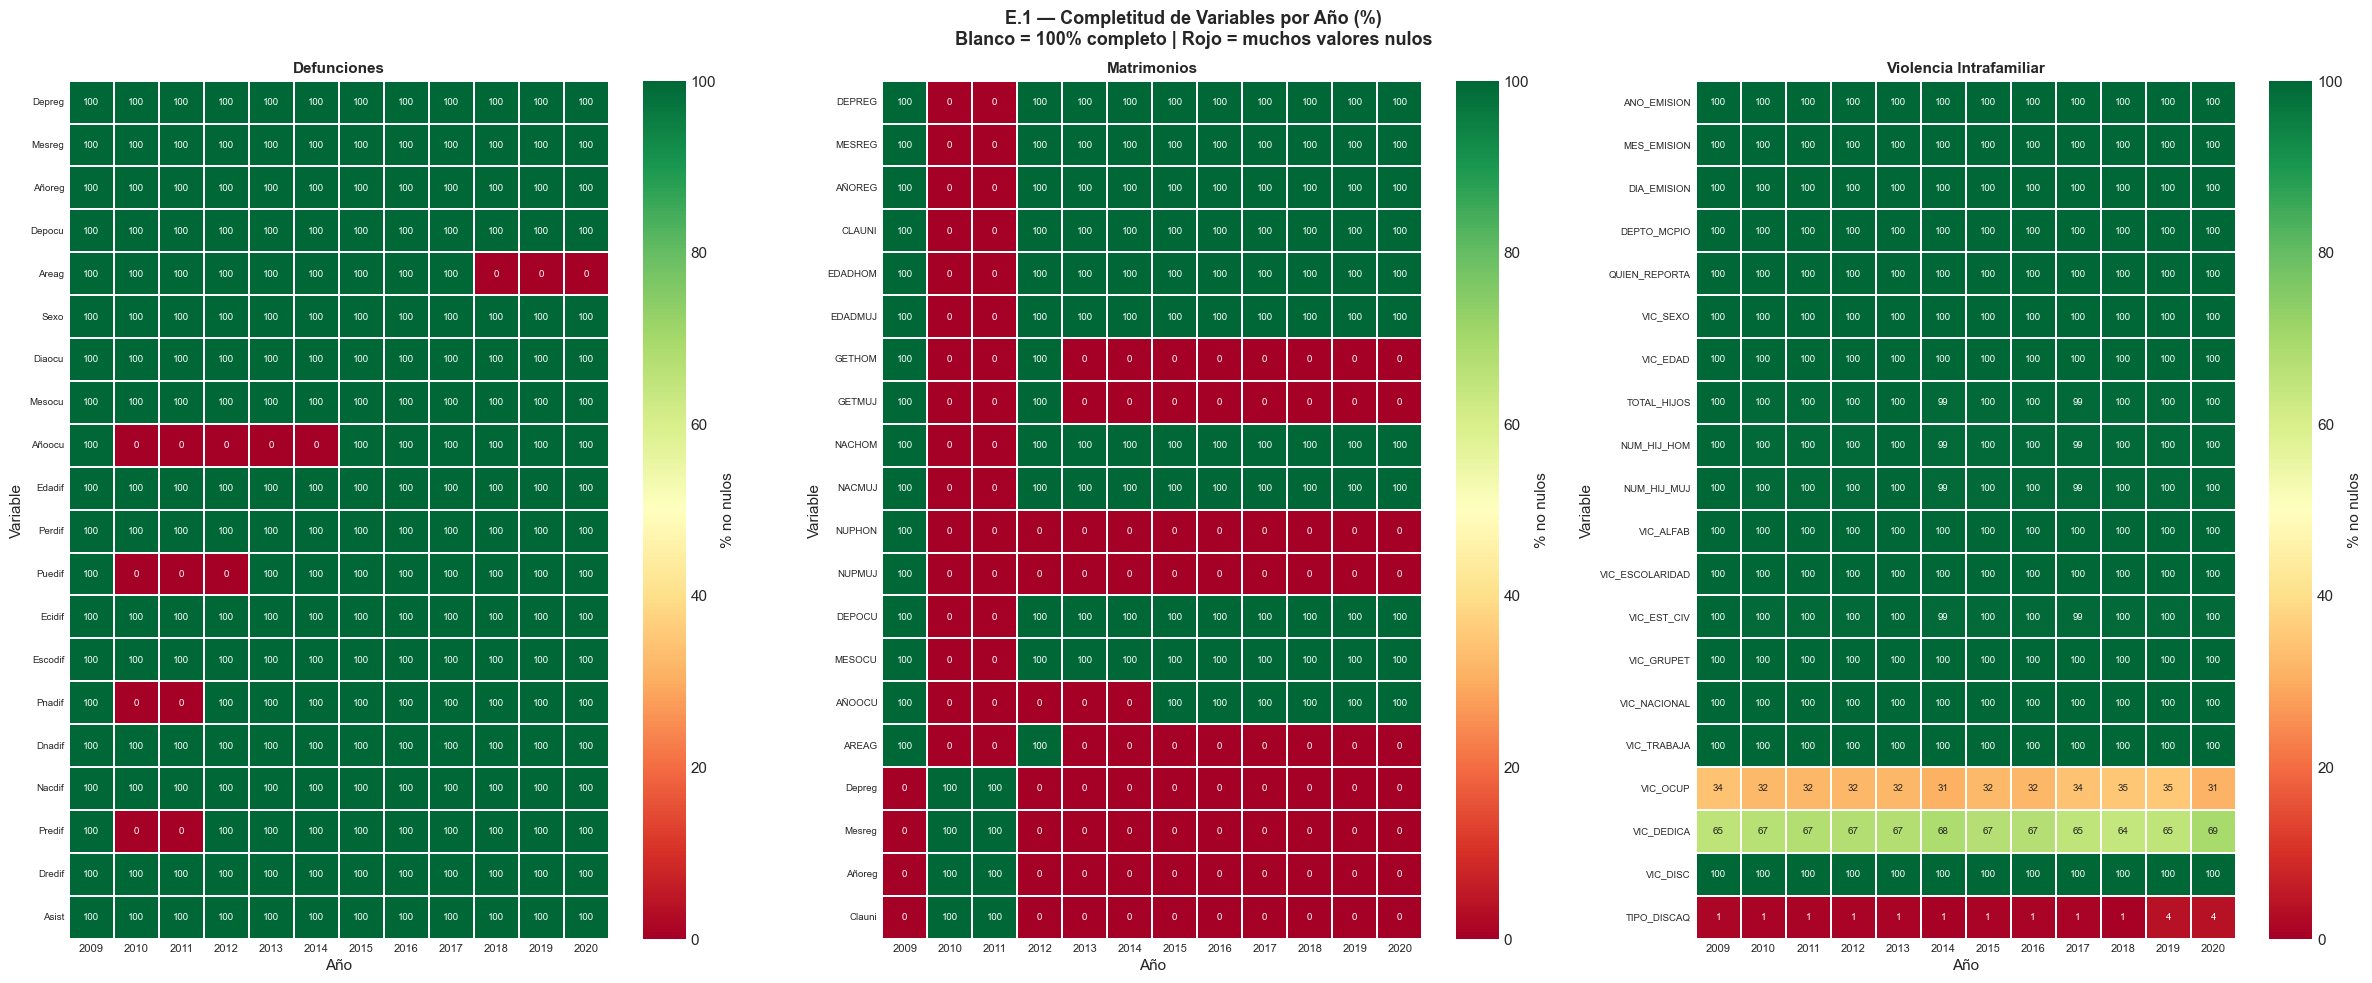

In [67]:
print("="*80)
print("E.1 — HEATMAP DE COMPLETITUD PORCENTUAL (variables × años)")
print("="*80)

def completitud_anio(df, col_anio='ANIO', max_cols=20):
    """Devuelve DataFrame con % completitud por (variable, año)."""
    cols_num = df.select_dtypes(include=[np.number]).columns.tolist()
    if col_anio in cols_num:
        cols_num.remove(col_anio)
    cols_num = cols_num[:max_cols]
    result = {}
    for año in sorted(df[col_anio].unique()):
        sub = df[df[col_anio] == año][cols_num]
        result[año] = (sub.notna().mean() * 100).round(1)
    return pd.DataFrame(result).T

datasets_completitud = [
    (df_defunciones, 'ANIO', 'Defunciones'),
    (df_matrimonios, 'ANIO', 'Matrimonios'),
    (df_violencia,   'ANIO', 'Violencia Intrafamiliar'),
]

fig, axes = plt.subplots(1, 3, figsize=(24, 10))
fig.suptitle('E.1 — Completitud de Variables por Año (%)\nBlanco = 100% completo | Rojo = muchos valores nulos',
             fontsize=13, fontweight='bold')

for ax, (df_src, ca, titulo) in zip(axes, datasets_completitud):
    comp = completitud_anio(df_src, col_anio=ca)
    sns.heatmap(comp.T, ax=ax, cmap='RdYlGn', vmin=0, vmax=100,
                annot=True, fmt='.0f', annot_kws={'size': 7},
                linewidths=0.3, cbar_kws={'label': '% no nulos'})
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.set_xlabel('Año'); ax.set_ylabel('Variable')
    ax.tick_params(axis='x', labelsize=8); ax.tick_params(axis='y', labelsize=7)

plt.tight_layout()
plt.show()


---
## E.2 — Evolución Temporal: Tasas de Variación Interanual vs Bandas Históricas

Las tasas de cambio % permiten ver en escala común los tres fenómenos. Las bandas de ±1 desviación estándar histórica (2010-2019) muestran qué años son realmente atípicos en términos de variación, no de magnitud absoluta.

E.2 — TASAS DE VARIACIÓN INTERANUAL CON BANDAS DE ±1 DESVIACIÓN ESTÁNDAR


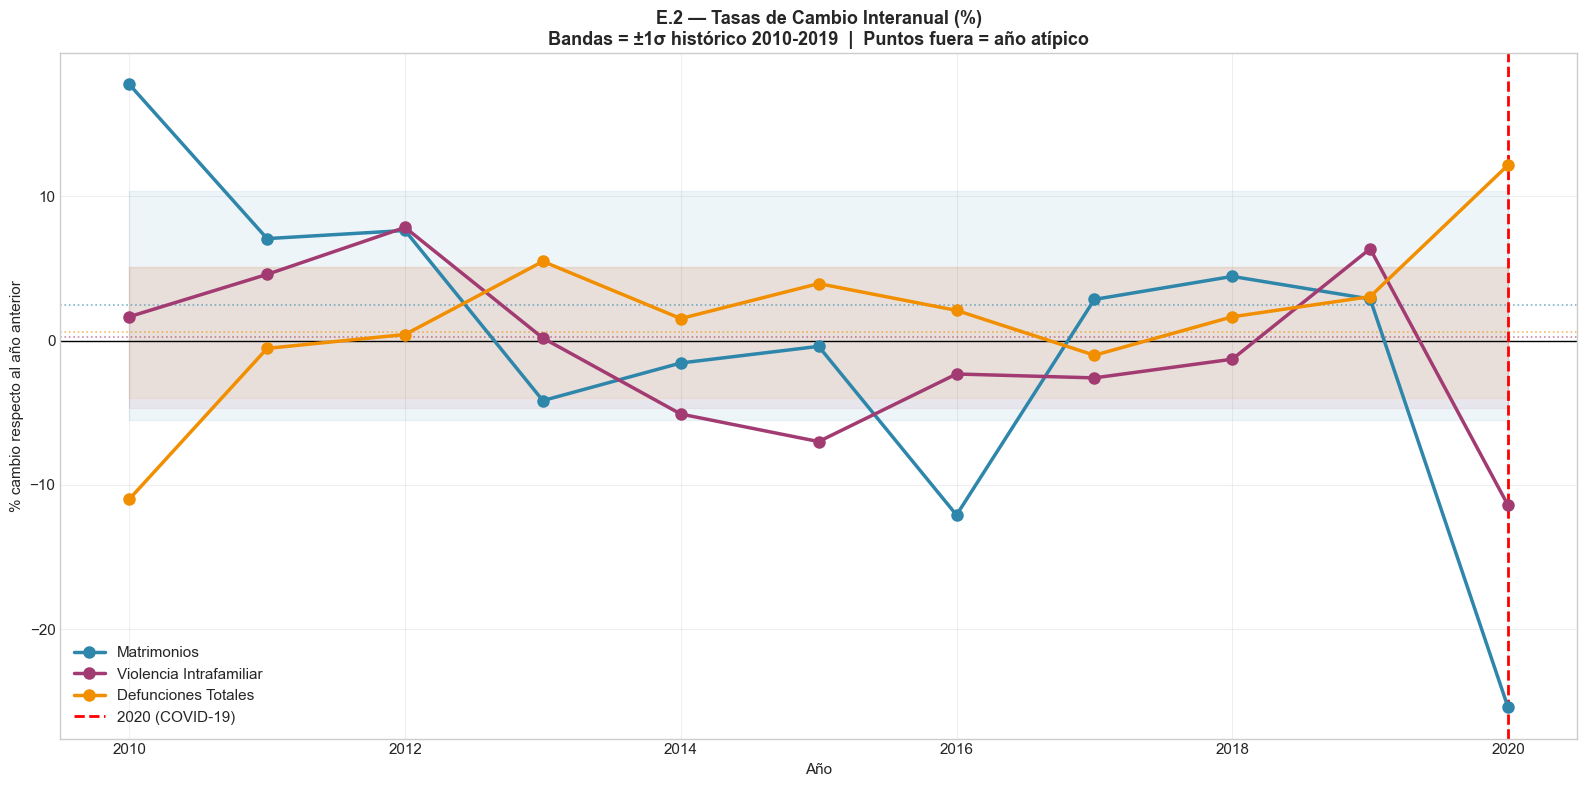


Años con variación fuera de ±1σ histórico:
  Matrimonios                     2010: +17.7%  ↑ alza
  Matrimonios                     2016: -12.1%  ↓ baja
  Matrimonios                     2020: -25.4%  ↓ baja
  Violencia Intrafamiliar         2012: +7.8%  ↑ alza
  Violencia Intrafamiliar         2014: -5.1%  ↓ baja
  Violencia Intrafamiliar         2015: -7.0%  ↓ baja
  Violencia Intrafamiliar         2019: +6.4%  ↑ alza
  Violencia Intrafamiliar         2020: -11.4%  ↓ baja
  Defunciones Totales             2010: -11.0%  ↓ baja
  Defunciones Totales             2013: +5.5%  ↑ alza
  Defunciones Totales             2020: +12.2%  ↑ alza


In [68]:
print("="*80)
print("E.2 — TASAS DE VARIACIÓN INTERANUAL CON BANDAS DE ±1 DESVIACIÓN ESTÁNDAR")
print("="*80)

fig, ax = plt.subplots(figsize=(16, 8))

for col, color in zip(COLS, ['#2E86AB','#A23B72','#F18F01']):
    pct_vals = df_tendencias[col + '_PctChange'].values
    años_pct  = df_tendencias['Año'].values

    # Referencia histórica: 2010-2019
    pct_hist = pct_vals[(años_pct >= 2010) & (años_pct <= 2019)]
    mu, sigma = np.mean(pct_hist), np.std(pct_hist, ddof=1)

    ax.plot(años_pct[1:], pct_vals[1:], marker='o', lw=2.5, ms=8,
            color=color, label=LABELS[col], zorder=3)
    ax.fill_between(años_pct[1:], mu - sigma, mu + sigma, alpha=0.08, color=color)
    ax.axhline(mu, color=color, ls=':', lw=1.2, alpha=0.6)

ax.axhline(0, color='black', lw=1)
ax.axvline(2020, color='red', ls='--', lw=2, label='2020 (COVID-19)')
ax.set_title('E.2 — Tasas de Cambio Interanual (%)\nBandas = ±1σ histórico 2010-2019  |  Puntos fuera = año atípico',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Año'); ax.set_ylabel('% cambio respecto al año anterior')
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Identificar años atípicos
print("\nAños con variación fuera de ±1σ histórico:")
for col in COLS:
    pct_vals = df_tendencias[col + '_PctChange'].values
    años_pct  = df_tendencias['Año'].values
    pct_hist  = pct_vals[(años_pct >= 2010) & (años_pct <= 2019)]
    mu, sigma = np.mean(pct_hist), np.std(pct_hist, ddof=1)
    atipicos = [(a, v) for a, v in zip(años_pct[1:], pct_vals[1:]) if abs(v - mu) > sigma]
    if atipicos:
        for a, v in atipicos:
            dir_str = "↑ alza" if v > mu else "↓ baja"
            print(f"  {LABELS[col]:30s}  {a}: {v:+.1f}%  {dir_str}")


---
## E.3 — Heatmaps Geográficos: % Intra-año por Departamento × Año

Tres heatmaps lado a lado (defunciones, violencia, matrimonios) con la participación porcentual de cada departamento respecto al total nacional de ese año. Los departamentos están ordenados por su tasa promedio (2009-2019). Esto permite ver fenómenos locales que los conteos absolutos ocultan.

E.3 — HEATMAPS GEOGRÁFICOS: % INTRA-AÑO POR DEPARTAMENTO × AÑO


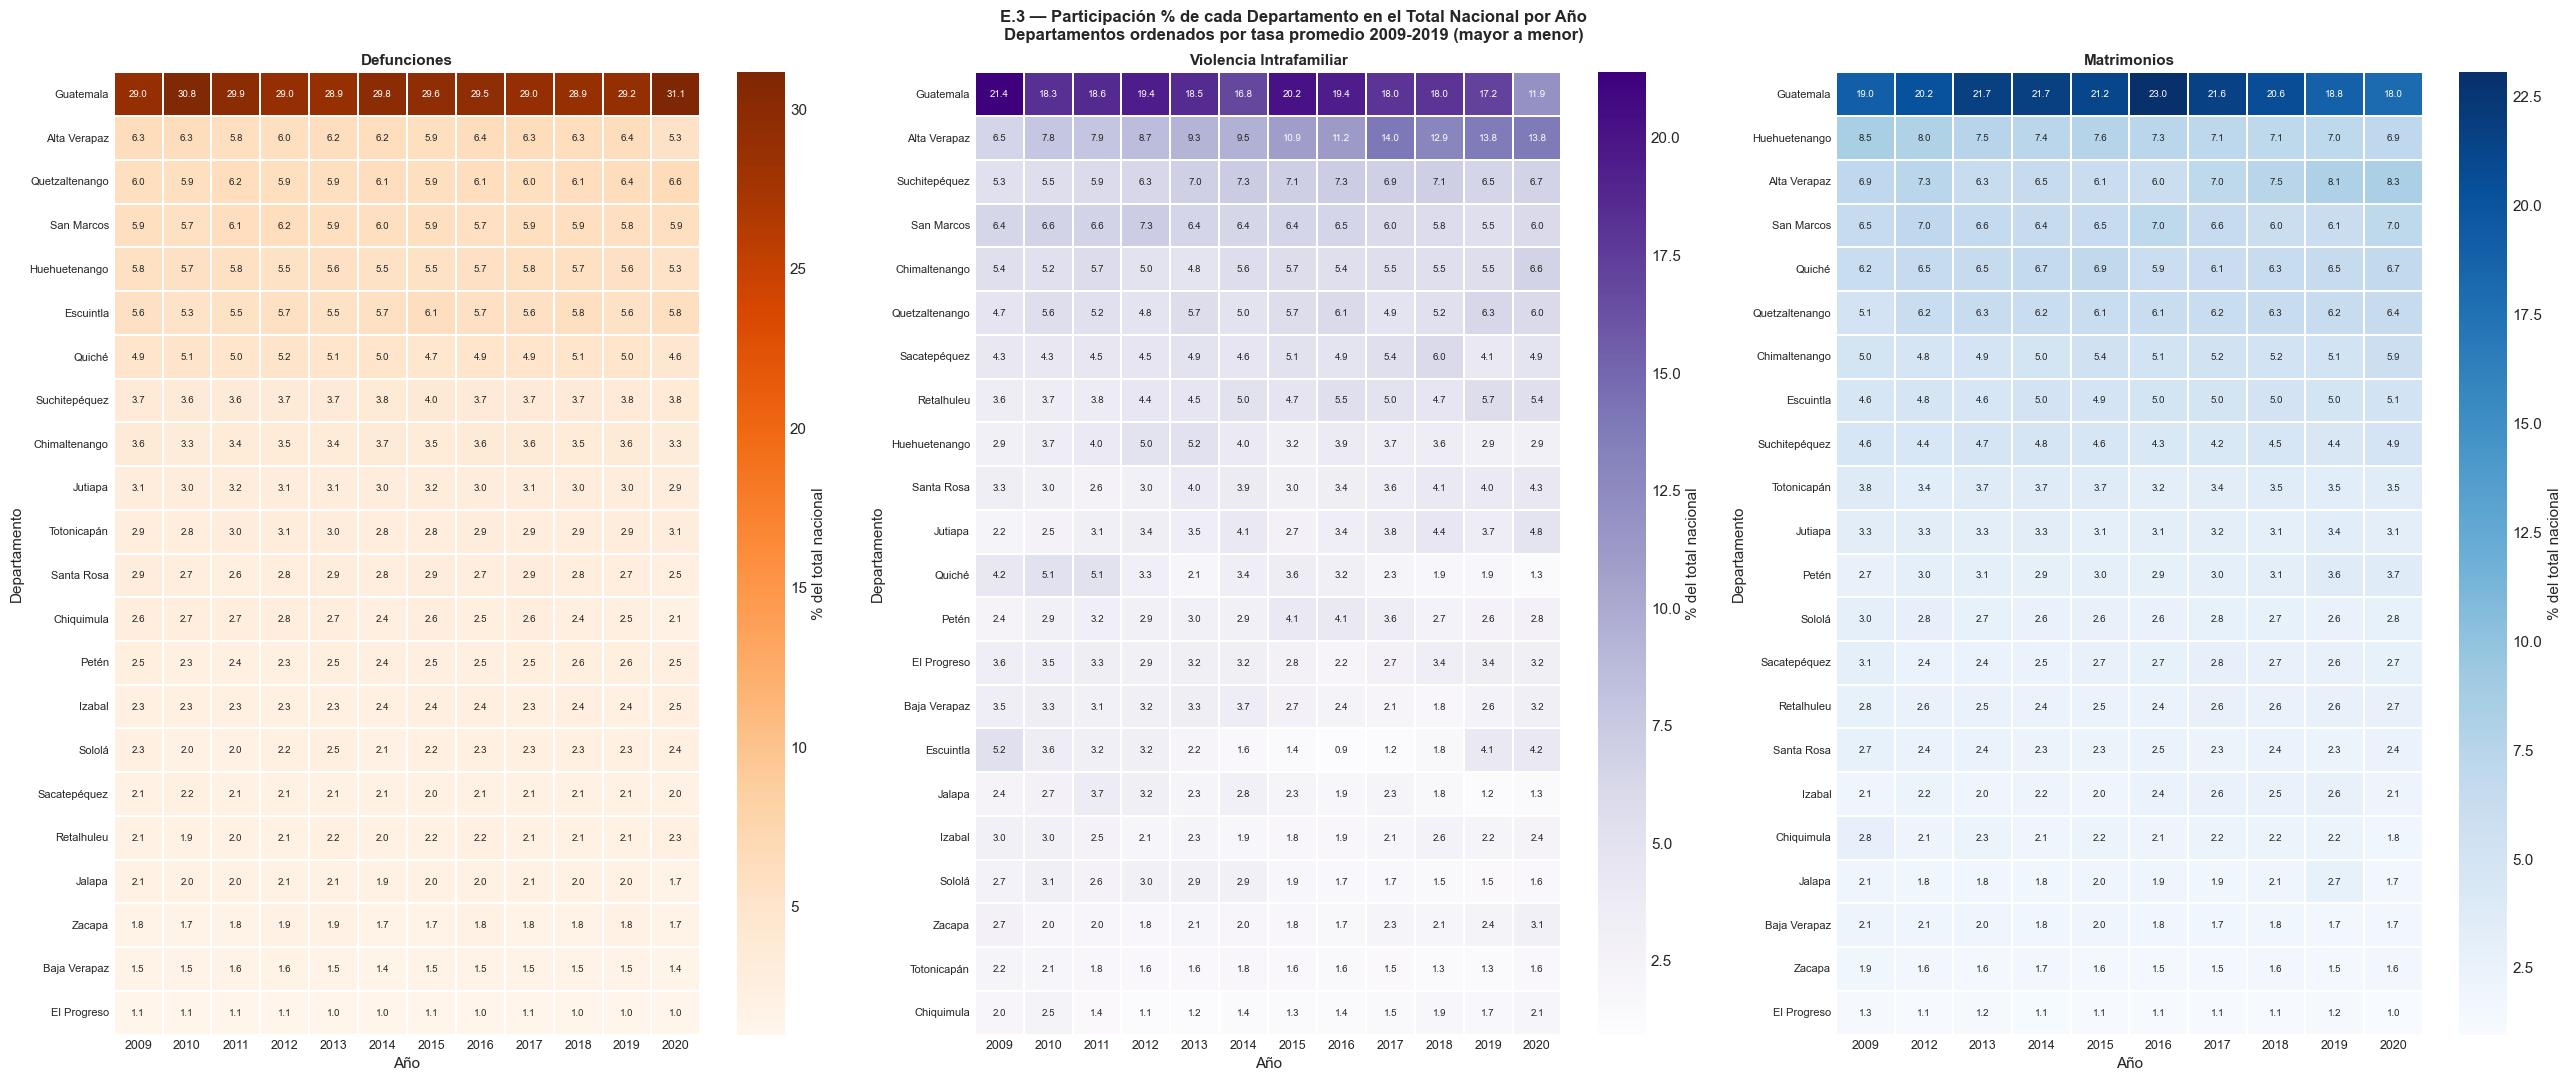

In [69]:
print("="*80)
print("E.3 — HEATMAPS GEOGRÁFICOS: % INTRA-AÑO POR DEPARTAMENTO × AÑO")
print("="*80)

fig, axes = plt.subplots(1, 3, figsize=(26, 11))
fig.suptitle('E.3 — Participación % de cada Departamento en el Total Nacional por Año\n'
             'Departamentos ordenados por tasa promedio 2009-2019 (mayor a menor)',
             fontsize=12, fontweight='bold')

datasets_geo = [
    (pct_def, 'Defunciones',              'Oranges', pct_prom_def),
    (pct_vio, 'Violencia Intrafamiliar',  'Purples', pct_prom_vio),
    (pct_mat, 'Matrimonios',              'Blues',   pct_prom_mat),
]

for ax, (pct_df, titulo, cmap, orden) in zip(axes, datasets_geo):
    pivot = pct_df.pivot(index='Departamento', columns='ANIO', values='PctNacional').fillna(0)
    pivot = pivot.reindex(orden.index)  # ordenar por promedio histórico
    sns.heatmap(pivot, ax=ax, cmap=cmap, annot=True, fmt='.1f',
                annot_kws={'size': 7}, linewidths=0.3,
                cbar_kws={'label': '% del total nacional'})
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.set_xlabel('Año'); ax.set_ylabel('Departamento')
    ax.tick_params(axis='x', labelsize=9); ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()


---
## E.4 — Perfiles Demográficos Porcentuales e Índice de Feminización

E.4 — PERFILES DEMOGRÁFICOS PORCENTUALES + ÍNDICE DE FEMINIZACIÓN


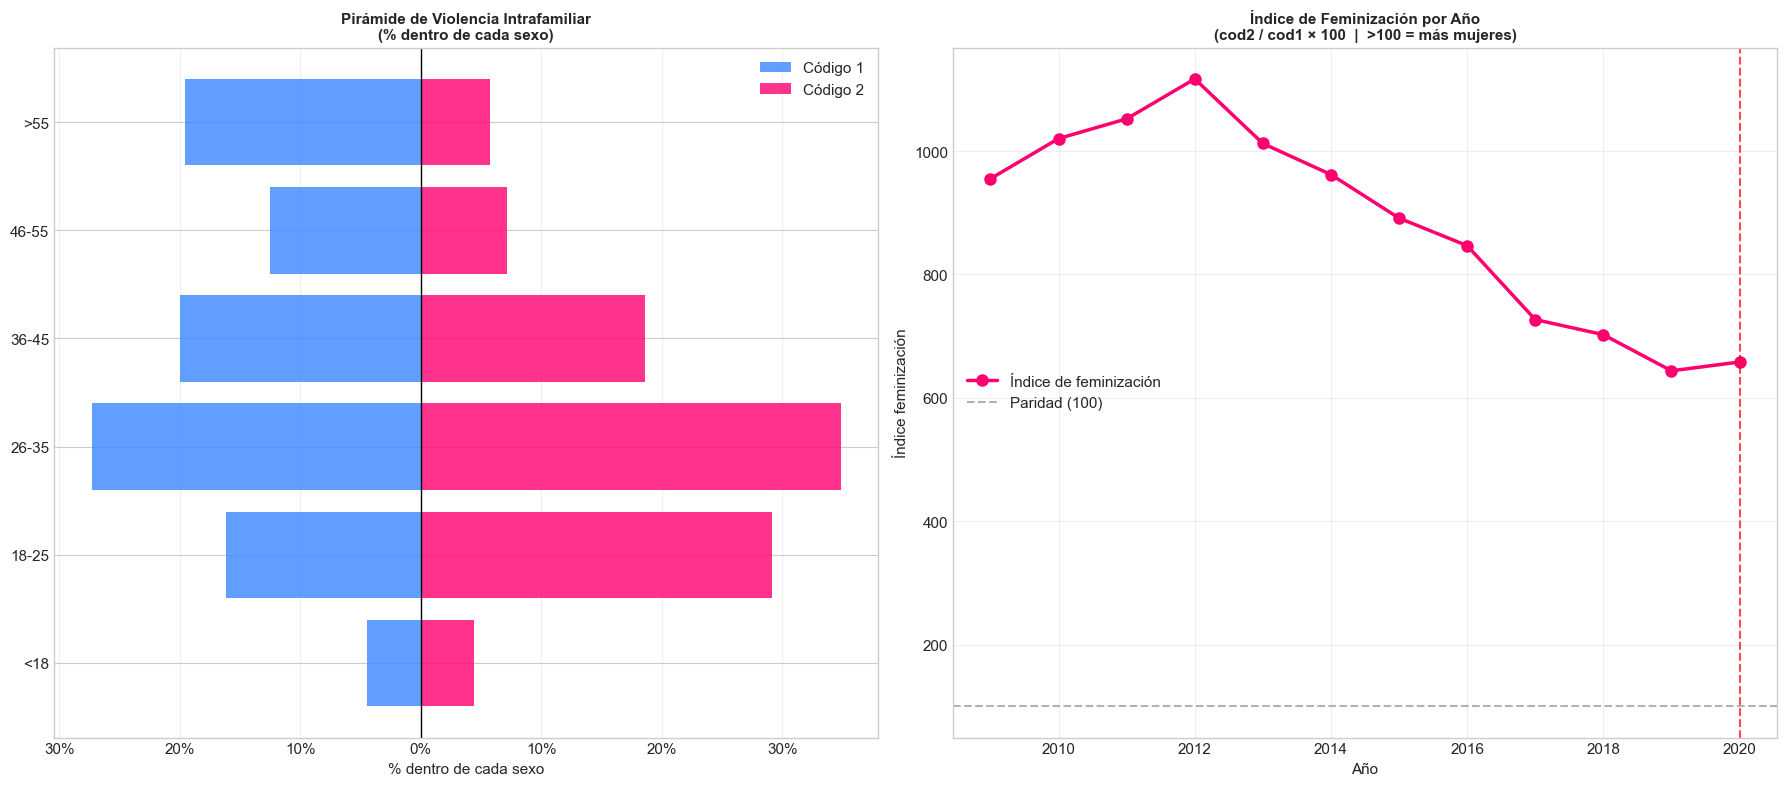

In [70]:
print("="*80)
print("E.4 — PERFILES DEMOGRÁFICOS PORCENTUALES + ÍNDICE DE FEMINIZACIÓN")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# ── Panel 1: Pirámide de violencia intrafamiliar en porcentajes ────────────────
if col_edad(df_violencia) and col_sexo(df_violencia):
    ea = col_edad(df_violencia); sa = col_sexo(df_violencia)
    df_violencia['GrupoEdad'] = pd.cut(df_violencia[ea], bins=BINS_EDAD, labels=LABS_EDAD)
    sexo_vals = sorted(df_violencia[sa].dropna().unique())

    todos = df_violencia['GrupoEdad'].value_counts(normalize=True) * 100

    if len(sexo_vals) >= 2:
        sv1, sv2 = sexo_vals[0], sexo_vals[1]
        s1 = (df_violencia[df_violencia[sa] == sv1]['GrupoEdad']
              .value_counts(normalize=True).reindex(LABS_EDAD, fill_value=0) * 100)
        s2 = (df_violencia[df_violencia[sa] == sv2]['GrupoEdad']
              .value_counts(normalize=True).reindex(LABS_EDAD, fill_value=0) * 100)

        y = np.arange(len(LABS_EDAD))
        axes[0].barh(y,  -s1.values, color='#3A86FF', alpha=0.8, label=f'Código {int(sv1)}')
        axes[0].barh(y,   s2.values, color='#FF006E', alpha=0.8, label=f'Código {int(sv2)}')
        axes[0].set_yticks(y); axes[0].set_yticklabels(LABS_EDAD)
        axes[0].axvline(0, color='black', lw=1)
        xticks = axes[0].get_xticks()
        axes[0].set_xticklabels([f'{abs(t):.0f}%' for t in xticks])
        axes[0].set_title('Pirámide de Violencia Intrafamiliar\n(% dentro de cada sexo)',
                           fontsize=11, fontweight='bold')
        axes[0].set_xlabel('% dentro de cada sexo'); axes[0].legend(); axes[0].grid(axis='x', alpha=0.3)

# ── Panel 2: Índice de feminización por año ────────────────────────────────────
if col_sexo(df_violencia):
    sa = col_sexo(df_violencia)
    anual_sexo = df_violencia.groupby(['ANIO', sa]).size().unstack(fill_value=0)
    if len(anual_sexo.columns) >= 2:
        sv1, sv2 = sorted(anual_sexo.columns)[:2]
        indice_fem = (anual_sexo[sv2] / anual_sexo[sv1].replace(0, np.nan) * 100).fillna(0)
        axes[1].plot(indice_fem.index, indice_fem.values, marker='o', lw=2.5, ms=8,
                     color='#FF006E', label='Índice de feminización')
        axes[1].axhline(100, color='gray', ls='--', lw=1.5, alpha=0.6, label='Paridad (100)')
        axes[1].axvline(2020, color='red', ls='--', lw=1.5, alpha=0.7)
        axes[1].set_title('Índice de Feminización por Año\n(cod2 / cod1 × 100  |  >100 = más mujeres)',
                           fontsize=11, fontweight='bold')
        axes[1].set_xlabel('Año'); axes[1].set_ylabel('Índice feminización')
        axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---
## E.5 — Correlaciones sobre Tasas de Cambio (Spearman Robusto a Outliers)

Se recalcula la matriz de correlación usando las **tasas de variación interanual** en lugar de valores absolutos, y se usa **Spearman** (robusto a outliers) junto a Pearson para comparar. También se muestra el efecto de incluir/excluir 2020 en el coeficiente.

E.5 — CORRELACIONES: VALORES ABSOLUTOS vs TASAS DE CAMBIO vs SIN 2020

Comparación de correlaciones según la representación de los datos:
                                          Par Pearson (absolutos) Pearson (Δ%) Pearson (Δ%, sin 2020) Spearman (Δ%, sin 2020)
        Matrimonios × Violencia Intrafamiliar               0.791        0.694       0.456  (p=0.158)        0.627  (p=0.039)
            Matrimonios × Defunciones Totales              -0.719       -0.869      -0.763  (p=0.006)       -0.627  (p=0.039)
Violencia Intrafamiliar × Defunciones Totales              -0.766       -0.501      -0.191  (p=0.573)       -0.182  (p=0.593)


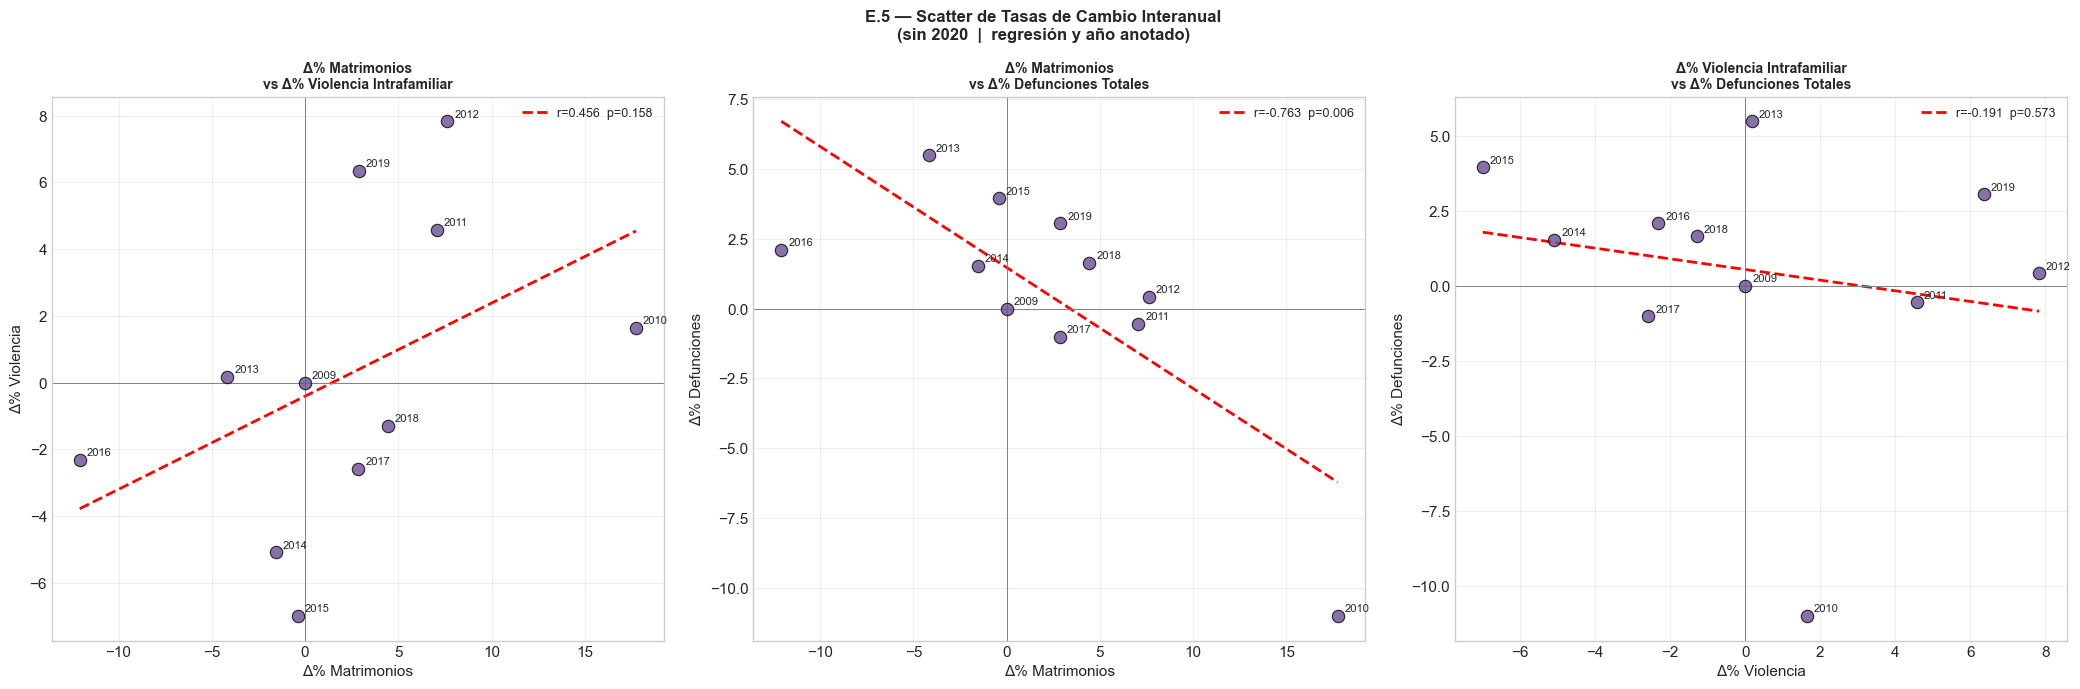

In [71]:
print("="*80)
print("E.5 — CORRELACIONES: VALORES ABSOLUTOS vs TASAS DE CAMBIO vs SIN 2020")
print("="*80)

pares = [('Matrimonios','Violencia'),('Matrimonios','Defunciones'),('Violencia','Defunciones')]

# Construir tabla comparativa
rows = []
for a, b in pares:
    # Con valores absolutos
    r_abs, p_abs = pearsonr(df_tendencias[a], df_tendencias[b])
    # Con tasas de cambio (todos los años)
    r_pct, p_pct = pearsonr(df_tendencias[a+'_PctChange'].values[1:],
                             df_tendencias[b+'_PctChange'].values[1:])
    # Con tasas de cambio sin 2020 (Pearson)
    mask = df_tendencias['Año'] != 2020
    v1 = df_tendencias.loc[mask, a+'_PctChange'].values
    v2 = df_tendencias.loc[mask, b+'_PctChange'].values
    r_pct_no20, p_pct_no20 = pearsonr(v1, v2)
    # Spearman sin 2020
    rs, ps = spearmanr(v1, v2)
    rows.append({
        'Par': f'{LABELS[a]} × {LABELS[b]}',
        'Pearson (absolutos)': f'{r_abs:.3f}',
        'Pearson (Δ%)': f'{r_pct:.3f}',
        'Pearson (Δ%, sin 2020)': f'{r_pct_no20:.3f}  (p={p_pct_no20:.3f})',
        'Spearman (Δ%, sin 2020)': f'{rs:.3f}  (p={ps:.3f})',
    })

df_corr_comp = pd.DataFrame(rows)
print("\nComparación de correlaciones según la representación de los datos:")
print(df_corr_comp.to_string(index=False))

# Scatter plots de tasas de cambio
fig, axes = plt.subplots(1, 3, figsize=(21, 7))
fig.suptitle('E.5 — Scatter de Tasas de Cambio Interanual\n(sin 2020  |  regresión y año anotado)',
             fontsize=12, fontweight='bold')

para_colores = {'Matrimonios':'#2E86AB','Violencia':'#A23B72','Defunciones':'#F18F01'}
for ax, (a, b) in zip(axes, pares):
    m_a = df_tendencias['Año'] != 2020
    x = df_tendencias.loc[m_a, a+'_PctChange'].values
    y = df_tendencias.loc[m_a, b+'_PctChange'].values
    anios = df_tendencias.loc[m_a, 'Año'].values
    ca_x, ca_y = para_colores[a], para_colores[b]

    ax.scatter(x, y, s=80, color='#6A4C93', alpha=0.8, edgecolors='black', lw=0.8, zorder=3)
    for xi, yi, ai in zip(x, y, anios):
        ax.annotate(str(ai), (xi, yi), fontsize=8, textcoords='offset points', xytext=(5, 3))

    if len(x) > 2:
        slope, intercept, rv, pv, _ = stats.linregress(x, y)
        xr = np.linspace(x.min(), x.max(), 50)
        ax.plot(xr, slope * xr + intercept, 'r--', lw=2,
                label=f'r={rv:.3f}  p={pv:.3f}')

    ax.axhline(0, color='gray', lw=0.7); ax.axvline(0, color='gray', lw=0.7)
    ax.set_title(f'Δ% {LABELS[a]}\nvs Δ% {LABELS[b]}', fontsize=10, fontweight='bold')
    ax.set_xlabel(f'Δ% {a}'); ax.set_ylabel(f'Δ% {b}')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---
# INCISO F — Clustering K-Means con Features Porcentuales por Departamento

**Mejora respecto al caso base:** El clustering anterior usaba valores absolutos de casos (dominado por Guatemala capital). Aquí los features son:
- **CAGR** (tasa de crecimiento anual compuesto %) usando participación porcentual
- **Coeficiente de variación** (%) de la participación anual
- **Variación máxima single-year** (%)
- **Pendiente de tendencia** sobre la participación (regresión lineal)
- **% promedio** del período (2009-2019)

Esto agrupa departamentos por su **patrón de intensidad relativa**, no por tamaño.

In [72]:
print("="*80)
print("F.1 — CONSTRUCCIÓN DE FEATURES PORCENTUALES POR DEPARTAMENTO")
print("="*80)

def features_porcentuales(pct_df, excluir_año=2020, nombre_dataset=''):
    """
    Construye features de dinámica temporal usando participación % intra-año.
    """
    ref = pct_df[pct_df['ANIO'] != excluir_año].copy()
    pivot = ref.pivot(index='Departamento', columns='ANIO', values='PctNacional').fillna(0)
    pivot = pivot.dropna()

    features = {}
    for depto in pivot.index:
        serie = pivot.loc[depto].values
        años_s = pivot.columns.values.astype(float)

        # Promedio de participación
        prom = np.mean(serie)

        # Coeficiente de variación (std/mean * 100)
        cv = (np.std(serie, ddof=1) / prom * 100) if prom > 0 else 0

        # CAGR usando % de participación
        v0, vn = serie[0], serie[-1]
        n = len(serie) - 1
        cagr = ((vn / v0) ** (1 / n) - 1) * 100 if v0 > 0 else 0

        # Variación máxima año a año
        diffs = np.diff(serie)
        max_var = np.max(np.abs(diffs))

        # Pendiente (tendencia lineal sobre la participación)
        if len(años_s) > 1:
            slope, _, _, _, _ = stats.linregress(años_s, serie)
        else:
            slope = 0

        # % de años por encima del promedio
        pct_sobre_promedio = np.mean(serie > prom) * 100

        features[depto] = {
            f'{nombre_dataset}_Promedio_Pct': prom,
            f'{nombre_dataset}_CV_Pct': cv,
            f'{nombre_dataset}_CAGR_Pct': cagr,
            f'{nombre_dataset}_MaxVar_Pct': max_var,
            f'{nombre_dataset}_Pendiente': slope,
            f'{nombre_dataset}_PctSobrePromedio': pct_sobre_promedio,
        }

    return pd.DataFrame(features).T

feats_vio = features_porcentuales(pct_vio, nombre_dataset='Vio')
feats_def = features_porcentuales(pct_def, nombre_dataset='Def')
feats_mat = features_porcentuales(pct_mat, nombre_dataset='Mat')

# Combinar por departamento (intersección)
df_features = feats_vio.join(feats_def, how='inner').join(feats_mat, how='inner')
df_features = df_features.fillna(0)

print(f"Features construidas: {df_features.shape[0]} departamentos × {df_features.shape[1]} variables")
print(f"\nVariables:")
for f in df_features.columns:
    print(f"  • {f}")
print(f"\nEstadísticos descriptivos:")
print(df_features.describe().round(3).to_string())


F.1 — CONSTRUCCIÓN DE FEATURES PORCENTUALES POR DEPARTAMENTO
Features construidas: 22 departamentos × 18 variables

Variables:
  • Vio_Promedio_Pct
  • Vio_CV_Pct
  • Vio_CAGR_Pct
  • Vio_MaxVar_Pct
  • Vio_Pendiente
  • Vio_PctSobrePromedio
  • Def_Promedio_Pct
  • Def_CV_Pct
  • Def_CAGR_Pct
  • Def_MaxVar_Pct
  • Def_Pendiente
  • Def_PctSobrePromedio
  • Mat_Promedio_Pct
  • Mat_CV_Pct
  • Mat_CAGR_Pct
  • Mat_MaxVar_Pct
  • Mat_Pendiente
  • Mat_PctSobrePromedio

Estadísticos descriptivos:
       Vio_Promedio_Pct  Vio_CV_Pct  Vio_CAGR_Pct  Vio_MaxVar_Pct  Vio_Pendiente  Vio_PctSobrePromedio  Def_Promedio_Pct  Def_CV_Pct  Def_CAGR_Pct  Def_MaxVar_Pct  Def_Pendiente  Def_PctSobrePromedio  Mat_Promedio_Pct  Mat_CV_Pct  Mat_CAGR_Pct  Mat_MaxVar_Pct  Mat_Pendiente  Mat_PctSobrePromedio
count           22.0000     22.0000       22.0000         22.0000        22.0000               22.0000           22.0000     22.0000       22.0000         22.0000        22.0000               22.0000    

F.2 — SELECCIÓN DE K ÓPTIMO (gráficas separadas)


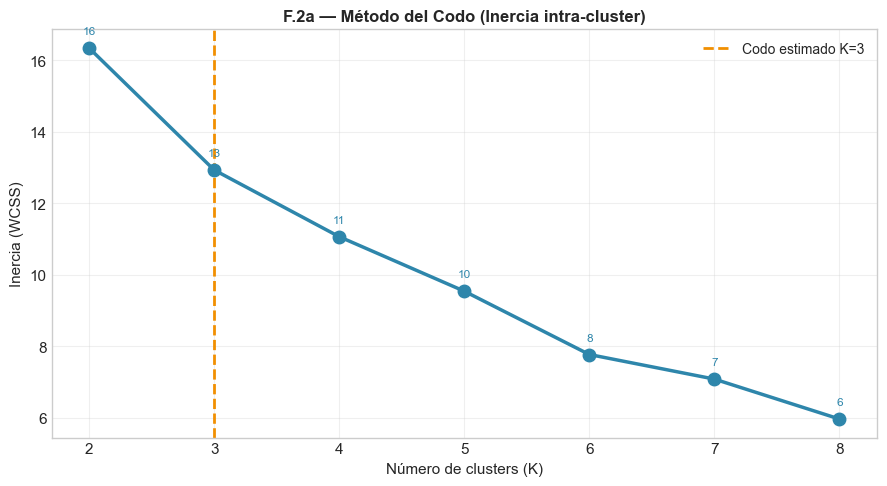

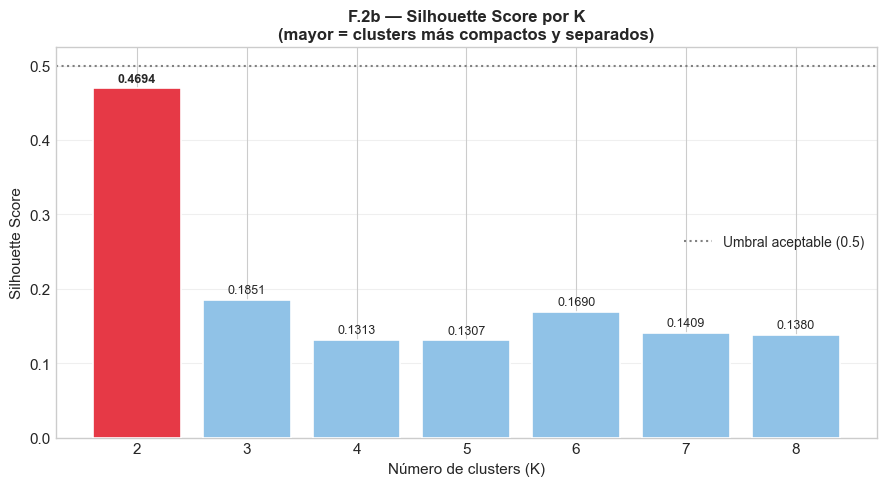


  Silhouette por K: {2: 0.4694, 3: 0.1851, 4: 0.1313, 5: 0.1307, 6: 0.169, 7: 0.1409, 8: 0.138}
  K óptimo por Silhouette : 2  (score = 0.4694)
  K codo estimado         : 3


In [73]:
print("="*80)
print("F.2 — SELECCIÓN DE K ÓPTIMO (gráficas separadas)")
print("="*80)

scaler = MinMaxScaler()
X = scaler.fit_transform(df_features.values)

inercias, silouettes = [], []
K_RANGE = range(2, min(len(df_features), 9))

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X)
    inercias.append(km.inertia_)
    silouettes.append(silhouette_score(X, labels))

ks = list(K_RANGE)

# ── Gráfica 1: Método del Codo ────────────────────────────────────────────────
delta2 = np.diff(np.diff(inercias))
k_codo = ks[1:-1][np.argmax(delta2)] if len(delta2) else ks[0]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(ks, inercias, marker='o', lw=2.5, ms=9, color='#2E86AB', zorder=3)
for kv, iv in zip(ks, inercias):
    ax.annotate(f'{iv:.0f}', (kv, iv), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=8.5, color='#2E86AB')
ax.axvline(k_codo, color='#F18F01', ls='--', lw=2, label=f'Codo estimado K={k_codo}')
ax.set_title('F.2a — Método del Codo (Inercia intra-cluster)', fontsize=12, fontweight='bold')
ax.set_xlabel('Número de clusters (K)', fontsize=11)
ax.set_ylabel('Inercia (WCSS)', fontsize=11)
ax.set_xticks(ks)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── Gráfica 2: Silhouette Score ──────────────────────────────────────────────
k_optimo = ks[np.argmax(silouettes)]
col_bars = ['#E63946' if k == k_optimo else '#90C2E7' for k in ks]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(ks, silouettes, color=col_bars, edgecolor='white', lw=1.2, zorder=3)
for bar, sv in zip(bars, silouettes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{sv:.4f}', ha='center', va='bottom', fontsize=9,
            fontweight='bold' if sv == max(silouettes) else 'normal')
ax.axhline(0.5, color='gray', ls=':', lw=1.5, label='Umbral aceptable (0.5)')
ax.set_title('F.2b — Silhouette Score por K\n(mayor = clusters más compactos y separados)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Número de clusters (K)', fontsize=11)
ax.set_ylabel('Silhouette Score', fontsize=11)
ax.set_xticks(ks)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f"\n  Silhouette por K: { {k: round(s,4) for k,s in zip(ks, silouettes)} }")
print(f"  K óptimo por Silhouette : {k_optimo}  (score = {max(silouettes):.4f})")
print(f"  K codo estimado         : {k_codo}")


F.3 — CLUSTERING FINAL CON K ÓPTIMO

Cluster 0  (21 departamentos): Alta Verapaz, Baja Verapaz, Chimaltenango, Chiquimula, El Progreso, Escuintla, Huehuetenango, Izabal, Jalapa, Jutiapa, Petén, Quetzaltenango, Quiché, Retalhuleu, Sacatepéquez, San Marcos, Santa Rosa, Sololá, Suchitepéquez, Totonicapán, Zacapa

Cluster 1  (1 departamentos): Guatemala


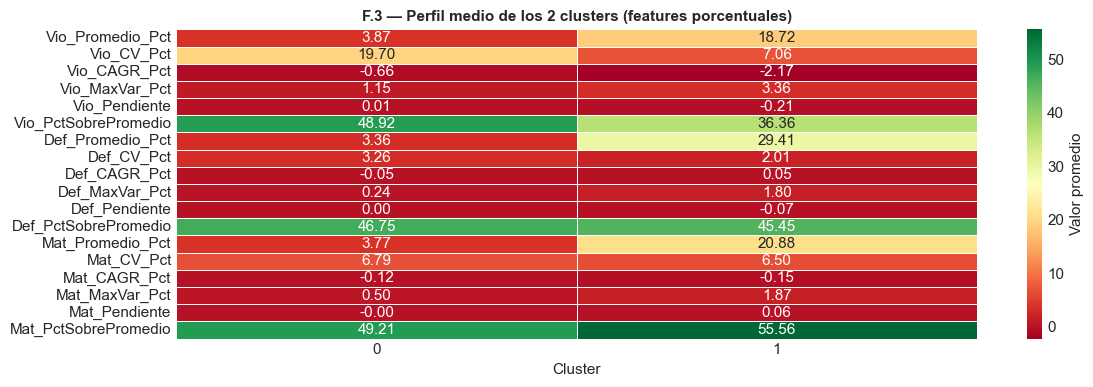

In [74]:
print("="*80)
print("F.3 — CLUSTERING FINAL CON K ÓPTIMO")
print("="*80)

km_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=50)
df_features['Cluster'] = km_final.fit_predict(X)

CLUSTER_COLORS = ['#E63946', '#457B9D', '#2A9D8F', '#E9C46A', '#F4A261', '#264653']

for c in range(k_optimo):
    deptos = df_features[df_features['Cluster'] == c].index.tolist()
    print(f"\nCluster {c}  ({len(deptos)} departamentos): {', '.join(deptos)}")

# Tabla de perfiles promedio por cluster
perfil = df_features.groupby('Cluster').mean(numeric_only=True)

fig, ax = plt.subplots(figsize=(max(12, k_optimo*4), 4))
sns.heatmap(
    perfil.T, annot=True, fmt='.2f', cmap='RdYlGn',
    ax=ax, linewidths=0.5, cbar_kws={'label': 'Valor promedio'}
)
ax.set_title(f'F.3 — Perfil medio de los {k_optimo} clusters (features porcentuales)', fontweight='bold', fontsize=11)
ax.set_xlabel('Cluster')
plt.tight_layout()
plt.show()


F.4 — VISUALIZACIÓN PCA 2D DE CLUSTERS


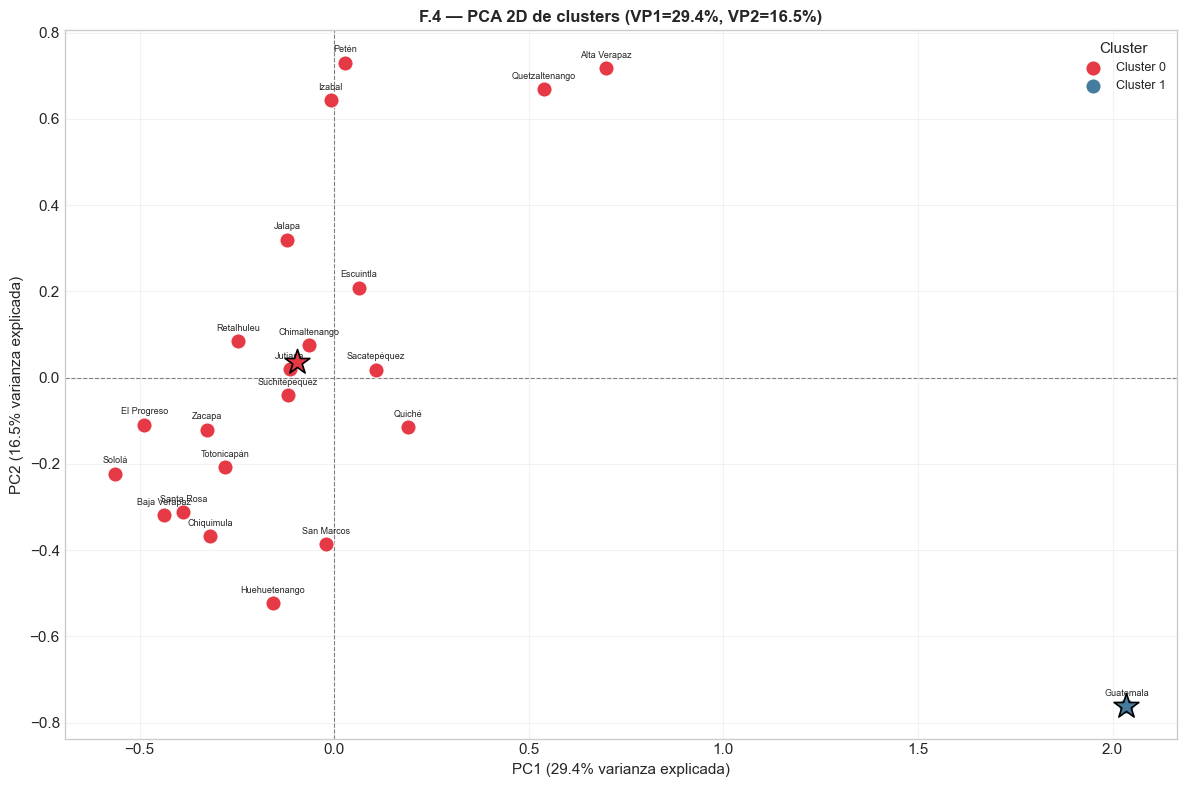


Varianza total explicada por 2 PC: 45.9%


In [75]:
print("="*80)
print("F.4 — VISUALIZACIÓN PCA 2D DE CLUSTERS")
print("="*80)

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X)
var1, var2 = pca.explained_variance_ratio_

df_pca = pd.DataFrame({
    'PC1': coords[:, 0],
    'PC2': coords[:, 1],
    'Cluster': df_features['Cluster'].values,
    'Departamento': df_features.index
})

fig, ax = plt.subplots(figsize=(12, 8))

for c in range(k_optimo):
    mask = df_pca['Cluster'] == c
    ax.scatter(
        df_pca.loc[mask, 'PC1'], df_pca.loc[mask, 'PC2'],
        label=f'Cluster {c}', s=120, color=CLUSTER_COLORS[c],
        edgecolors='white', linewidths=0.8, zorder=3
    )
    for _, row in df_pca[mask].iterrows():
        ax.annotate(row['Departamento'], (row['PC1'], row['PC2']),
                    fontsize=6.5, ha='center', va='bottom',
                    xytext=(0, 6), textcoords='offset points')

# Marcar centroides
centroids_pca = pca.transform(scaler.transform(perfil.values))
for c, (cx, cy) in enumerate(centroids_pca):
    ax.scatter(cx, cy, s=350, marker='*', color=CLUSTER_COLORS[c],
               edgecolors='black', linewidths=1.2, zorder=5)

ax.set_title(f'F.4 — PCA 2D de clusters (VP1={var1:.1%}, VP2={var2:.1%})',
             fontsize=12, fontweight='bold')
ax.set_xlabel(f'PC1 ({var1:.1%} varianza explicada)')
ax.set_ylabel(f'PC2 ({var2:.1%} varianza explicada)')
ax.legend(title='Cluster', loc='best', fontsize=9)
ax.grid(True, alpha=0.25)
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.axvline(0, color='gray', lw=0.8, ls='--')
plt.tight_layout()
plt.show()
print(f"\nVarianza total explicada por 2 PC: {var1+var2:.1%}")


F.5 — PERFILES PORCENTUALES POR CLUSTER


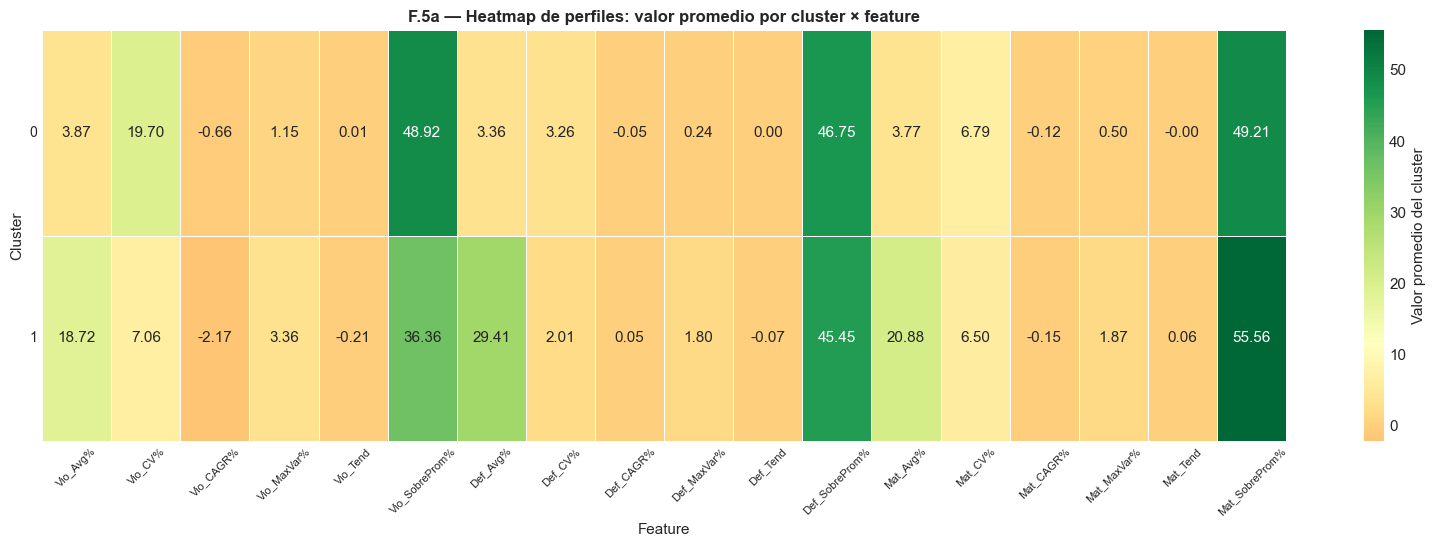

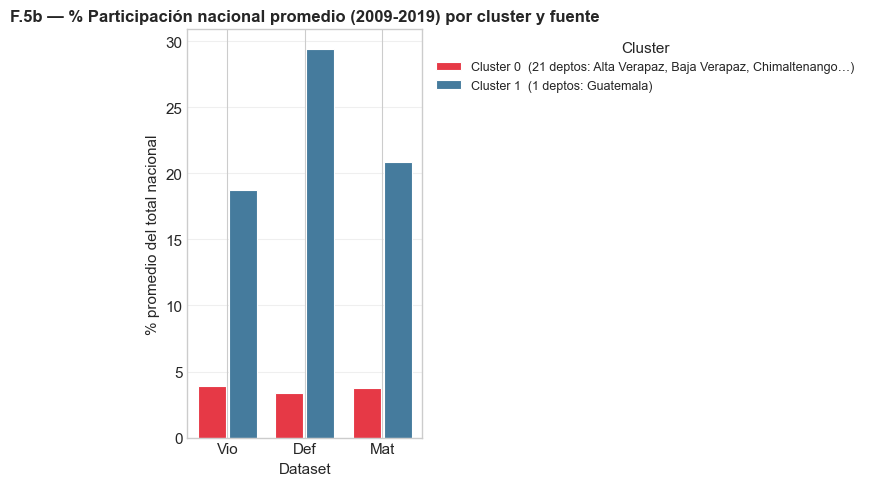


Perfiles promedio (% participación) por cluster:
         Vio_Promedio_Pct  Def_Promedio_Pct  Mat_Promedio_Pct
Cluster                                                      
0                  3.8700            3.3600            3.7700
1                 18.7200           29.4100           20.8800


In [76]:
print("="*80)
print("F.5 — PERFILES PORCENTUALES POR CLUSTER")
print("="*80)

PERFIL_COLS = [c for c in df_features.columns if c != 'Cluster']
perfil_real = df_features.groupby('Cluster')[PERFIL_COLS].mean()

short_labels = (
    perfil_real.columns
    .str.replace('_Promedio_Pct',   '_Avg%',      regex=False)
    .str.replace('_CV_Pct',         '_CV%',        regex=False)
    .str.replace('_CAGR_Pct',       '_CAGR%',      regex=False)
    .str.replace('_MaxVar_Pct',     '_MaxVar%',     regex=False)
    .str.replace('_PctSobrePromedio','_SobreProm%', regex=False)
    .str.replace('_Pendiente',       '_Tend',       regex=False)
)

# ── Gráfica 1: Heatmap features × cluster ────────────────────────────────────
fig, ax = plt.subplots(figsize=(max(14, len(PERFIL_COLS)*0.9), k_optimo*1.8 + 2))
sns.heatmap(
    perfil_real,
    ax=ax, annot=True, fmt='.2f',
    cmap='RdYlGn', center=perfil_real.values.mean(),
    linewidths=0.5, linecolor='white',
    xticklabels=short_labels,
    cbar_kws={'label': 'Valor promedio del cluster'}
)
ax.set_title('F.5a — Heatmap de perfiles: valor promedio por cluster × feature',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Feature'); ax.set_ylabel('Cluster')
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=10)
plt.tight_layout()
plt.show()

# ── Gráfica 2: Barras agrupadas — participación % media por fuente ───────────
promedio_cols = [c for c in PERFIL_COLS if '_Promedio_Pct' in c]
if promedio_cols:
    perfil_avg = perfil_real[promedio_cols].copy()
    perfil_avg.columns = [c.replace('_Promedio_Pct', '') for c in promedio_cols]
    x = np.arange(len(perfil_avg.columns))
    w = 0.8 / k_optimo

    fig, ax = plt.subplots(figsize=(max(7, len(promedio_cols)*2.5), 5))
    for ci in range(k_optimo):
        deptos_c = df_features[df_features['Cluster'] == ci].index.tolist()
        label    = f'Cluster {ci}  ({len(deptos_c)} deptos: {", ".join(deptos_c[:3])}{"…" if len(deptos_c)>3 else ""})'
        ax.bar(x + ci*w - (k_optimo-1)*w/2,
               perfil_avg.loc[ci],
               width=w*0.9, color=CLUSTER_COLORS[ci],
               label=label, edgecolor='white', lw=0.8)

    ax.set_title('F.5b — % Participación nacional promedio (2009-2019) por cluster y fuente',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Dataset', fontsize=11)
    ax.set_ylabel('% promedio del total nacional', fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(perfil_avg.columns, fontsize=11)
    ax.legend(title='Cluster', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

print("\nPerfiles promedio (% participación) por cluster:")
cols_show = promedio_cols if promedio_cols else PERFIL_COLS[:6]
print(perfil_real[cols_show].round(2).to_string())


In [77]:
import os

print("="*80)
print("RESUMEN FINAL")
print("="*80)

os.makedirs('data/procesada', exist_ok=True)
df_features.to_csv('data/procesada/features_y_clusters.csv')
print("  ✓ data/procesada/features_y_clusters.csv")

print("\n" + "="*80)
print(f"NOTEBOOK COMPLETO — {len(df_features)} departamentos, {k_optimo} clusters")
print(f"Varianza PCA explicada: {(var1+var2):.1%}")
print(f"Silhouette final: {silhouette_score(X, df_features['Cluster'].values):.4f}")
print("="*80)


RESUMEN FINAL
  ✓ data/procesada/features_y_clusters.csv

NOTEBOOK COMPLETO — 22 departamentos, 2 clusters
Varianza PCA explicada: 45.9%
Silhouette final: 0.4694


## G. Clustering sin Guatemala
Guatemala concentra una fracción desproporcionada de los registros nacionales, lo que puede atraer los centroides hacia él y oscurecer los patrones del resto de departamentos. Esta sección repite el pipeline completo (F.1 – F.5) excluyendo Guatemala del espacio de features, para evaluar si los agrupamientos son más interpretables.

In [82]:
print("="*80)
print("G.1 — FEATURES SIN GUATEMALA")
print("="*80)

EXCLUIR_SGT   = ['Guatemala']
FEAT_COLS_SGT = [c for c in df_features.columns if c != 'Cluster']   # 18 features only

df_feat_sgt = (df_features
               .drop(index=EXCLUIR_SGT, errors='ignore')
               [FEAT_COLS_SGT]
               .copy())

print(f"Departamentos en análisis original : {len(df_features)}")
print(f"Departamentos excluidos            : {EXCLUIR_SGT}")
print(f"Departamentos en análisis sin Gt   : {len(df_feat_sgt)}")
print(f"Features                           : {df_feat_sgt.shape[1]}")
print(f"\nParticipación % promedio de Guatemala (referencia):")
if 'Guatemala' in df_features.index:
    gt_row = df_features.loc['Guatemala', [c for c in FEAT_COLS_SGT if '_Promedio_Pct' in c]]
    print(gt_row.round(2).to_string())


G.1 — FEATURES SIN GUATEMALA
Departamentos en análisis original : 22
Departamentos excluidos            : ['Guatemala']
Departamentos en análisis sin Gt   : 21
Features                           : 18

Participación % promedio de Guatemala (referencia):
Vio_Promedio_Pct   18.7200
Def_Promedio_Pct   29.4100
Mat_Promedio_Pct   20.8800


G.2 — SELECCIÓN DE K (sin Guatemala)


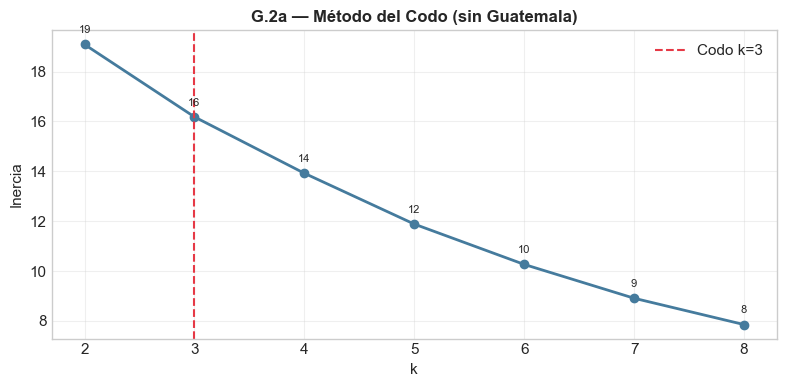

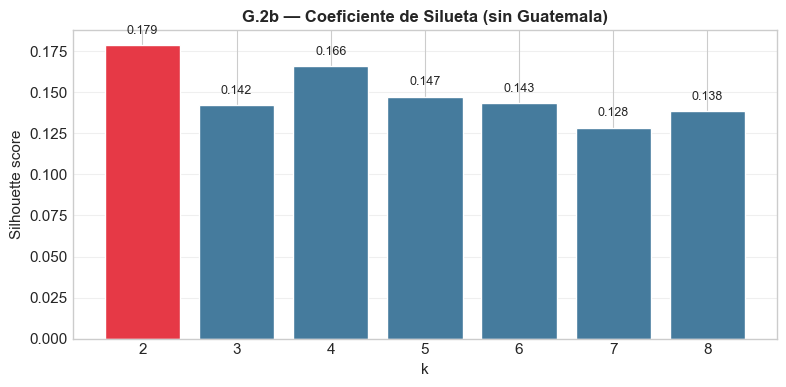


Silhouette scores: {2: 0.179, 3: 0.142, 4: 0.166, 5: 0.147, 6: 0.143, 7: 0.128, 8: 0.138}
k por codo        : 3
k óptimo silueta  : 2


In [83]:
print("="*80)
print("G.2 — SELECCIÓN DE K (sin Guatemala)")
print("="*80)

X_sgt        = MinMaxScaler().fit_transform(df_feat_sgt.values)
ks_sgt       = list(range(2, min(len(df_feat_sgt), 9)))
inercias_sgt = []
silouettes_sgt = []

for k in ks_sgt:
    km_tmp = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels_tmp = km_tmp.fit_predict(X_sgt)
    inercias_sgt.append(km_tmp.inertia_)
    silouettes_sgt.append(silhouette_score(X_sgt, labels_tmp))

# k por segunda derivada (codo)
delta2_sgt = np.diff(np.diff(inercias_sgt))
k_codo_sgt = ks_sgt[1:-1][int(np.argmax(delta2_sgt))]

# k por silueta máxima
k_optimo_sgt = ks_sgt[int(np.argmax(silouettes_sgt))]

# ── Elbow ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ks_sgt, inercias_sgt, 'o-', color='#457B9D', lw=2)
for k, v in zip(ks_sgt, inercias_sgt):
    ax.annotate(f'{v:.0f}', (k, v), textcoords='offset points', xytext=(0, 8),
                ha='center', fontsize=8)
ax.axvline(k_codo_sgt, color='#E63946', ls='--', lw=1.5, label=f'Codo k={k_codo_sgt}')
ax.set_title('G.2a — Método del Codo (sin Guatemala)', fontsize=12, fontweight='bold')
ax.set_xlabel('k'); ax.set_ylabel('Inercia')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# ── Silhouette ─────────────────────────────────────────────────────────────
col_bars_sgt = ['#E63946' if k == k_optimo_sgt else '#457B9D' for k in ks_sgt]
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(ks_sgt, silouettes_sgt, color=col_bars_sgt, edgecolor='white')
for bar, sv in zip(bars, silouettes_sgt):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{sv:.3f}', ha='center', va='bottom', fontsize=9)
ax.set_title('G.2b — Coeficiente de Silueta (sin Guatemala)', fontsize=12, fontweight='bold')
ax.set_xlabel('k'); ax.set_ylabel('Silhouette score')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

print(f"\nSilhouette scores: { {k: round(s, 3) for k, s in zip(ks_sgt, silouettes_sgt)} }")
print(f"k por codo        : {k_codo_sgt}")
print(f"k óptimo silueta  : {k_optimo_sgt}")


G.3 — KMEANS FINAL  k=3  (sin Guatemala)

Composición de clusters:

  Cluster 0 (12 deptos): Baja Verapaz, Chiquimula, El Progreso, Izabal, Jalapa, Petén, Retalhuleu, Sacatepéquez, Santa Rosa, Sololá, Totonicapán, Zacapa

  Cluster 1 (7 deptos): Chimaltenango, Escuintla, Huehuetenango, Jutiapa, Quiché, San Marcos, Suchitepéquez

  Cluster 2 (2 deptos): Alta Verapaz, Quetzaltenango


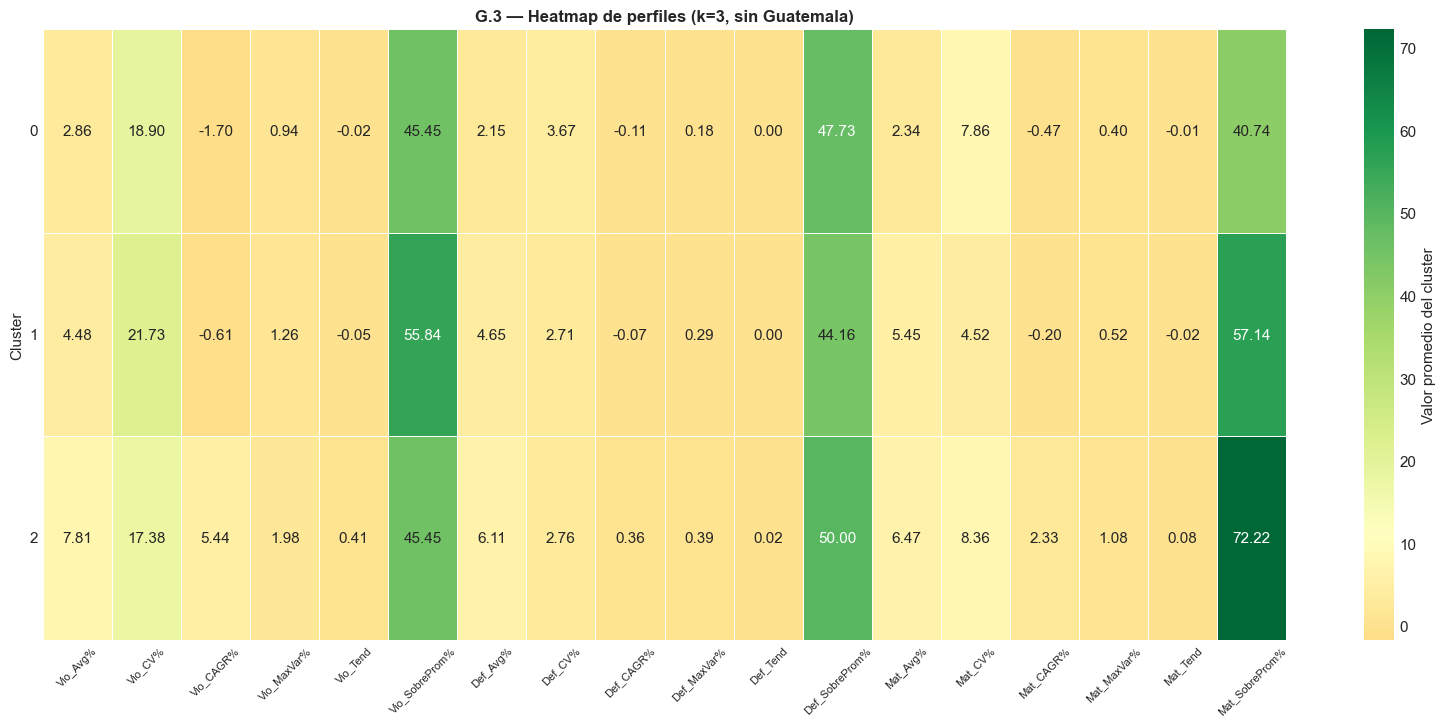


════════════════════════════════════════════════════════════════════════════════
CARACTERIZACIÓN DE CLUSTERS  (k=3, sin Guatemala)
════════════════════════════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────────────────
  CLUSTER 0  ▸  Baja Verapaz, Chiquimula, El Progreso, Izabal, Jalapa, Petén, Retalhuleu, Sacatepéquez, Santa Rosa, Sololá, Totonicapán, Zacapa
──────────────────────────────────────────────────────────────────────
  Métrica                                     Valor   Relativo al resto
  Violencia (% nac. promedio)                 2.86  ▼   3.28 vs resto
  Defunciones (% nac. promedio)               2.15  ▼   3.22 vs resto
  Matrimonios (% nac. promedio)               2.34  ▼   3.62 vs resto
  Violencia CV%                              18.90  ▼   0.65 vs resto
  Defunciones CV%                             3.67  ▲   0.94 vs resto
  Matrimonios CV%                             7.86  ▲   1.42 vs resto
  Violen

In [89]:
K_SGT = 3      # k forzado para experimento sin Guatemala
print("="*80)
print(f"G.3 — KMEANS FINAL  k={K_SGT}  (sin Guatemala)")
print("="*80)

km_sgt = KMeans(n_clusters=K_SGT, random_state=42, n_init=50)
km_sgt.fit(X_sgt)
df_feat_sgt = df_feat_sgt.drop(columns='Cluster', errors='ignore')
df_feat_sgt['Cluster'] = km_sgt.labels_
k_optimo_sgt = K_SGT    # sincronizar variable usada en G.4

COLS_PERFIL_SGT = [c for c in df_feat_sgt.columns if c != 'Cluster']
perfil_sgt = df_feat_sgt.groupby('Cluster')[COLS_PERFIL_SGT].mean()

# ── Composición ────────────────────────────────────────────────────────────
print("\nComposición de clusters:")
for c in range(K_SGT):
    deptos_c = df_feat_sgt[df_feat_sgt['Cluster'] == c].index.tolist()
    print(f"\n  Cluster {c} ({len(deptos_c)} deptos): {', '.join(deptos_c)}")

# ── Heatmap de perfiles ────────────────────────────────────────────────────
short_sgt = (perfil_sgt.columns
    .str.replace('_Promedio_Pct',    '_Avg%',       regex=False)
    .str.replace('_CV_Pct',          '_CV%',         regex=False)
    .str.replace('_CAGR_Pct',        '_CAGR%',       regex=False)
    .str.replace('_MaxVar_Pct',      '_MaxVar%',      regex=False)
    .str.replace('_PctSobrePromedio','_SobreProm%',  regex=False)
    .str.replace('_Pendiente',        '_Tend',        regex=False))

fig, ax = plt.subplots(figsize=(max(14, len(COLS_PERFIL_SGT)*0.9), K_SGT*1.8 + 2))
sns.heatmap(perfil_sgt, ax=ax, annot=True, fmt='.2f',
            cmap='RdYlGn', center=perfil_sgt.values.mean(),
            linewidths=0.5, linecolor='white',
            xticklabels=short_sgt,
            cbar_kws={'label': 'Valor promedio del cluster'})
ax.set_title(f'G.3 — Heatmap de perfiles (k={K_SGT}, sin Guatemala)',
             fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout(); plt.show()

# ── Caracterización detallada por cluster ──────────────────────────────────
avg_cols = [c for c in COLS_PERFIL_SGT if '_Promedio_Pct' in c]
cv_cols  = [c for c in COLS_PERFIL_SGT if '_CV_Pct'       in c]
cagr_cols= [c for c in COLS_PERFIL_SGT if '_CAGR_Pct'     in c]

ETIQUETAS = {
    'Vio_Promedio_Pct': 'Violencia (% nac. promedio)',
    'Def_Promedio_Pct': 'Defunciones (% nac. promedio)',
    'Mat_Promedio_Pct': 'Matrimonios (% nac. promedio)',
    'Vio_CV_Pct': 'Violencia CV%',
    'Def_CV_Pct': 'Defunciones CV%',
    'Mat_CV_Pct': 'Matrimonios CV%',
    'Vio_CAGR_Pct': 'Violencia CAGR%',
    'Def_CAGR_Pct': 'Defunciones CAGR%',
    'Mat_CAGR_Pct': 'Matrimonios CAGR%',
}

print("\n" + "═"*80)
print("CARACTERIZACIÓN DE CLUSTERS  (k=3, sin Guatemala)")
print("═"*80)
for c in range(K_SGT):
    deptos_c = df_feat_sgt[df_feat_sgt['Cluster'] == c].index.tolist()
    row_c    = perfil_sgt.loc[c]
    print(f"\n{'─'*70}")
    print(f"  CLUSTER {c}  ▸  {', '.join(deptos_c)}")
    print(f"{'─'*70}")
    print(f"  {'Métrica':<40} {'Valor':>8}  {'Relativo al resto':>18}")

    otros = perfil_sgt.drop(index=c).mean()

    for col, etq in ETIQUETAS.items():
        if col not in row_c.index:
            continue
        val   = row_c[col]
        ref   = otros[col]
        delta = val - ref
        flecha = '▲' if delta > 0 else '▼'
        print(f"  {etq:<40} {val:>7.2f}  {flecha} {abs(delta):>6.2f} vs resto")

    vio_cagr = row_c.get('Vio_CAGR_Pct', 0)
    def_cagr = row_c.get('Def_CAGR_Pct', 0)
    mat_cagr = row_c.get('Mat_CAGR_Pct', 0)
    trend    = ('creciente' if (vio_cagr + def_cagr + mat_cagr) / 3 > 0 else 'decreciente')
    stab_vio = 'estable' if row_c.get('Vio_CV_Pct', 100) < 20 else 'variable'
    print(f"\n  ➜ Tendencia general: {trend} | Violencia: {stab_vio}")


G.3b — INTERPRETACIÓN POR CLUSTER  (Violencia · Defunciones · Matrimonios)

Resumen de indicadores clave por cluster:
         Vio % nac. prom.  Def % nac. prom.  Mat % nac. prom.  Vio CAGR %  Def CAGR %  Mat CAGR %  Vio CV %  Mat CV %
Cluster                                                                                                              
0                  2.8600            2.1500            2.3400     -1.7000     -0.1100     -0.4700   18.9000    7.8600
1                  4.4800            4.6500            5.4500     -0.6100     -0.0700     -0.2000   21.7300    4.5200
2                  7.8100            6.1100            6.4700      5.4400      0.3600      2.3300   17.3800    8.3600


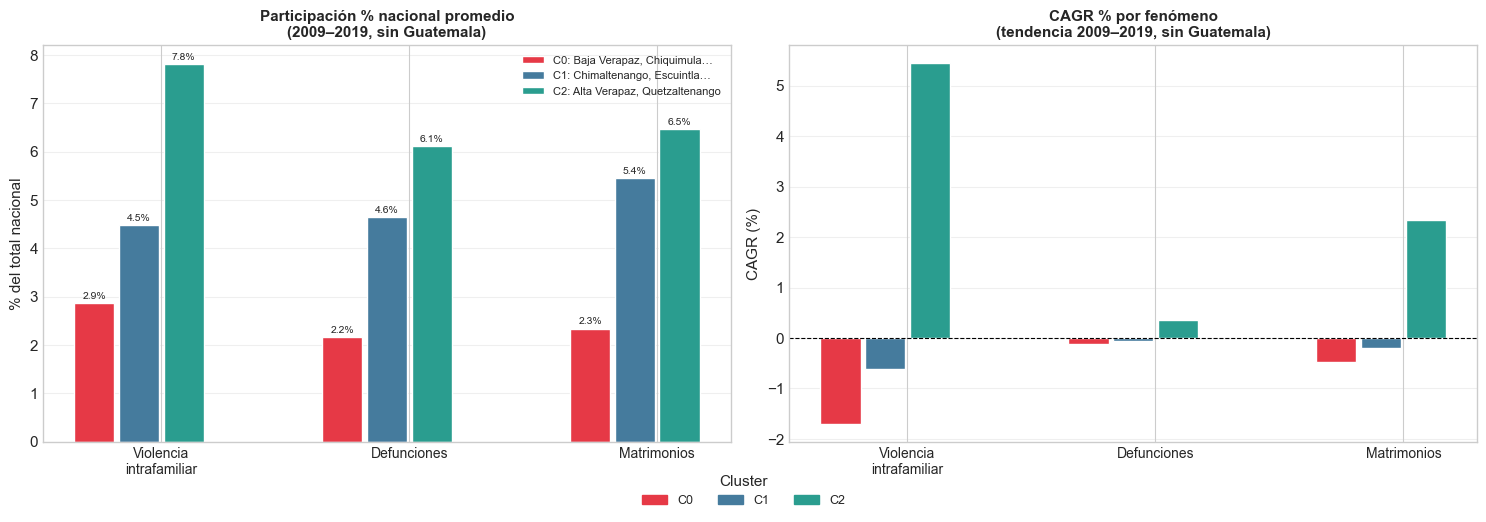


════════════════════════════════════════════════════════════════════════════════
PERFIL CONTEXTUAL DE CADA CLUSTER
════════════════════════════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────────────────
  CLUSTER 0  (12 deptos)
  Baja Verapaz, Chiquimula, El Progreso, Izabal, Jalapa, Petén, Retalhuleu, Sacatepéquez, Santa Rosa, Sololá, Totonicapán, Zacapa
──────────────────────────────────────────────────────────────────────
  Violencia intrafamiliar : baja (2.9% nac.), tendencia decreciente (-1.7%/año)
  Defunciones             : baja (2.2% nac.), CAGR -0.11%/año
  Matrimonios             : baja (2.3% nac.), tendencia estable, variabilidad media (CV=7.9%)
  Consistencia violencia  : 45% de los años superaron el promedio propio
  Relación Vio↔Mat        : ↓ Ambos decrecen → posible pérdida de peso relativo del departamento

──────────────────────────────────────────────────────────────────────
  CLUSTER 1  (7 deptos)
  C

In [90]:
print("="*80)
print("G.3b — INTERPRETACIÓN POR CLUSTER  (Violencia · Defunciones · Matrimonios)")
print("="*80)

# ── Tabla comparativa ─────────────────────────────────────────────────────
clave = {
    'Vio_Promedio_Pct' : 'Vio % nac. prom.',
    'Def_Promedio_Pct' : 'Def % nac. prom.',
    'Mat_Promedio_Pct' : 'Mat % nac. prom.',
    'Vio_CAGR_Pct'     : 'Vio CAGR %',
    'Def_CAGR_Pct'     : 'Def CAGR %',
    'Mat_CAGR_Pct'     : 'Mat CAGR %',
    'Vio_CV_Pct'       : 'Vio CV %',
    'Mat_CV_Pct'       : 'Mat CV %',
}
resumen = perfil_sgt[[c for c in clave if c in perfil_sgt.columns]].rename(columns=clave)
print("\nResumen de indicadores clave por cluster:")
print(resumen.round(2).to_string())

# ── Gráfica 1: % participación nacional promedio ───────────────────────────
avg_show = ['Vio_Promedio_Pct', 'Def_Promedio_Pct', 'Mat_Promedio_Pct']
labels_avg = ['Violencia\nintrafamiliar', 'Defunciones', 'Matrimonios']
x = np.arange(len(avg_show))
w = 0.18

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax1 = axes[0]
for ci in range(K_SGT):
    vals_avg = [perfil_sgt.loc[ci, c] for c in avg_show]
    deptos_ci = df_feat_sgt[df_feat_sgt['Cluster'] == ci].index.tolist()
    lbl = f'C{ci}: {", ".join(deptos_ci[:2])}{"…" if len(deptos_ci)>2 else ""}'
    bars_ci = ax1.bar(x + ci*w - 1.5*w, vals_avg, width=w*0.9,
                      color=CLUSTER_COLORS[ci], label=lbl, edgecolor='white')
    for bar, val in zip(bars_ci, vals_avg):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=7.5)

ax1.set_title('Participación % nacional promedio\n(2009–2019, sin Guatemala)',
              fontsize=11, fontweight='bold')
ax1.set_ylabel('% del total nacional')
ax1.set_xticks(x); ax1.set_xticklabels(labels_avg, fontsize=10)
ax1.legend(fontsize=8, loc='upper right')
ax1.grid(True, alpha=0.3, axis='y')

# ── Gráfica 2: CAGR (tendencia) ───────────────────────────────────────────
cagr_show  = ['Vio_CAGR_Pct', 'Def_CAGR_Pct', 'Mat_CAGR_Pct']
labels_cagr= ['Violencia\nintrafamiliar', 'Defunciones', 'Matrimonios']
ax2 = axes[1]
for ci in range(K_SGT):
    vals_cagr = [perfil_sgt.loc[ci, c] for c in cagr_show]
    ax2.bar(x + ci*w - 1.5*w, vals_cagr, width=w*0.9,
            color=CLUSTER_COLORS[ci], edgecolor='white')

ax2.axhline(0, color='black', lw=0.8, ls='--')
ax2.set_title('CAGR % por fenómeno\n(tendencia 2009–2019, sin Guatemala)',
              fontsize=11, fontweight='bold')
ax2.set_ylabel('CAGR (%)')
ax2.set_xticks(x); ax2.set_xticklabels(labels_cagr, fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

# leyenda compartida
handles = [plt.Rectangle((0,0),1,1, color=CLUSTER_COLORS[ci]) for ci in range(K_SGT)]
lbls_leg = [f'C{ci}' for ci in range(K_SGT)]
fig.legend(handles, lbls_leg, title='Cluster', loc='lower center',
           ncol=K_SGT, fontsize=9, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.show()

# ── Narrativa contextual ──────────────────────────────────────────────────
NARRATIVA = {}
for ci in range(K_SGT):
    row_n    = perfil_sgt.loc[ci]
    deptos_n = df_feat_sgt[df_feat_sgt['Cluster'] == ci].index.tolist()
    vio_avg  = row_n.get('Vio_Promedio_Pct', 0)
    def_avg  = row_n.get('Def_Promedio_Pct', 0)
    mat_avg  = row_n.get('Mat_Promedio_Pct', 0)
    vio_cagr = row_n.get('Vio_CAGR_Pct', 0)
    def_cagr = row_n.get('Def_CAGR_Pct', 0)
    mat_cagr = row_n.get('Mat_CAGR_Pct', 0)
    vio_cv   = row_n.get('Vio_CV_Pct', 0)
    mat_cv   = row_n.get('Mat_CV_Pct', 0)
    vio_sob  = row_n.get('Vio_PctSobrePromedio', 0)

    # Etiqueta de nivel
    nivel_vio = 'alta'    if vio_avg > 5   else ('media' if vio_avg > 3.5 else 'baja')
    nivel_def = 'alta'    if def_avg > 5   else ('media' if def_avg > 3.5 else 'baja')
    nivel_mat = 'alta'    if mat_avg > 5   else ('media' if mat_avg > 3.5 else 'baja')
    tend_vio  = 'creciente (+{:.1f}%/año)'.format(vio_cagr) if vio_cagr > 0.5 \
                else ('decreciente ({:.1f}%/año)'.format(vio_cagr) if vio_cagr < -0.5 else 'estable')
    tend_mat  = 'creciente (+{:.1f}%/año)'.format(mat_cagr) if mat_cagr > 0.5 \
                else ('decreciente ({:.1f}%/año)'.format(mat_cagr) if mat_cagr < -0.5 else 'estable')
    estab_mat = 'alta variabilidad' if mat_cv > 9 else ('variabilidad media' if mat_cv > 5 else 'variabilidad baja')

    NARRATIVA[ci] = (
        f"  Violencia intrafamiliar : {nivel_vio} ({vio_avg:.1f}% nac.), tendencia {tend_vio}\n"
        f"  Defunciones             : {nivel_def} ({def_avg:.1f}% nac.), CAGR {def_cagr:+.2f}%/año\n"
        f"  Matrimonios             : {nivel_mat} ({mat_avg:.1f}% nac.), tendencia {tend_mat}, {estab_mat} (CV={mat_cv:.1f}%)\n"
        f"  Consistencia violencia  : {vio_sob:.0f}% de los años superaron el promedio propio"
    )

print("\n" + "═"*80)
print("PERFIL CONTEXTUAL DE CADA CLUSTER")
print("═"*80)
for ci in range(K_SGT):
    deptos_n = df_feat_sgt[df_feat_sgt['Cluster'] == ci].index.tolist()
    row_n    = perfil_sgt.loc[ci]
    vio_avg  = row_n.get('Vio_Promedio_Pct', 0)
    def_avg  = row_n.get('Def_Promedio_Pct', 0)
    mat_avg  = row_n.get('Mat_Promedio_Pct', 0)
    vio_cagr = row_n.get('Vio_CAGR_Pct', 0)
    mat_cagr = row_n.get('Mat_CAGR_Pct', 0)

    # Relación entre violencia y matrimonios (posible señal de la problemática)
    if vio_cagr > 0 and mat_cagr < 0:
        relacion = "⚠ Violencia AUMENTA mientras matrimonios DECRECEN → posible vínculo problemático"
    elif vio_cagr < 0 and mat_cagr > 0:
        relacion = "✔ Violencia DECRECE mientras matrimonios CRECEN → dinámica favorable"
    elif vio_cagr > 0 and mat_cagr > 0:
        relacion = "↑ Ambos crecen → crecimiento demográfico general del departamento"
    else:
        relacion = "↓ Ambos decrecen → posible pérdida de peso relativo del departamento"

    print(f"\n{'─'*70}")
    print(f"  CLUSTER {ci}  ({len(deptos_n)} deptos)")
    print(f"  {', '.join(deptos_n)}")
    print(f"{'─'*70}")
    print(NARRATIVA[ci])
    print(f"  Relación Vio↔Mat        : {relacion}")


G.4 — PCA 2D  (sin Guatemala)


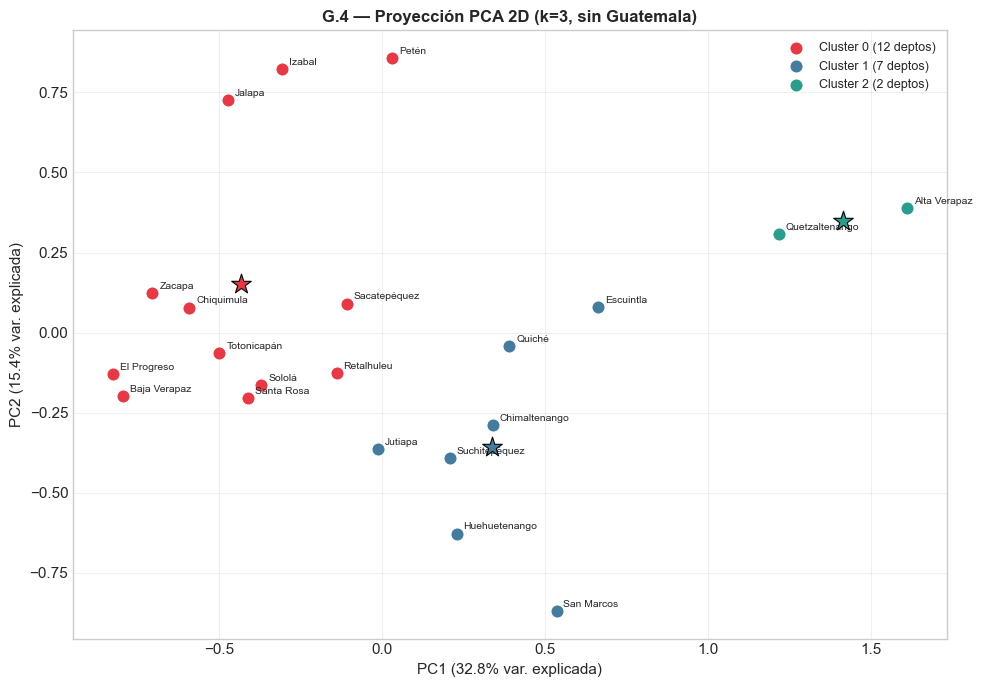


Varianza explicada: PC1=32.8%  PC2=15.4%  Total=48.2%

─── Asignación: CON Guatemala (F) vs SIN Guatemala (G) ───
                G_sinGt  F_conGt
Petén                 0        0
Sololá                0        0
Santa Rosa            0        0
Sacatepéquez          0        0
Retalhuleu            0        0
Totonicapán           0        0
Jalapa                0        0
Zacapa                0        0
El Progreso           0        0
Chiquimula            0        0
Baja Verapaz          0        0
Izabal                0        0
Huehuetenango         1        0
Jutiapa               1        0
Escuintla             1        0
Quiché                1        0
San Marcos            1        0
Chimaltenango         1        0
Suchitepéquez         1        0
Quetzaltenango        2        0
Alta Verapaz          2        0


In [91]:
print("="*80)
print("G.4 — PCA 2D  (sin Guatemala)")
print("="*80)

pca_sgt    = PCA(n_components=2, random_state=42)
coords_sgt = pca_sgt.fit_transform(X_sgt)
df_pca_sgt = pd.DataFrame(coords_sgt, columns=['PC1', 'PC2'], index=df_feat_sgt.index)
df_pca_sgt['Cluster'] = km_sgt.labels_

var1_sgt, var2_sgt = pca_sgt.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(10, 7))
for c in range(k_optimo_sgt):
    mask = df_pca_sgt['Cluster'] == c
    sub  = df_pca_sgt[mask]
    ax.scatter(sub['PC1'], sub['PC2'],
               color=CLUSTER_COLORS[c], s=90, zorder=3,
               label=f'Cluster {c} ({mask.sum()} deptos)', edgecolors='white', lw=0.8)
    for dep, row in sub.iterrows():
        ax.annotate(dep, (row['PC1'], row['PC2']),
                    textcoords='offset points', xytext=(5, 3), fontsize=7.5)

# Centroides en espacio PCA: transformar con MinMaxScaler ya ajustado en X_sgt
centroid_vals_sgt = MinMaxScaler().fit(df_feat_sgt[COLS_PERFIL_SGT].values).transform(
    df_feat_sgt.groupby('Cluster')[COLS_PERFIL_SGT].mean().values)
centroids_pca_sgt = pca_sgt.transform(centroid_vals_sgt)
for c, (cx, cy) in enumerate(centroids_pca_sgt):
    ax.scatter(cx, cy, marker='*', s=220, color=CLUSTER_COLORS[c],
               edgecolors='black', lw=0.8, zorder=4)

ax.set_title(f'G.4 — Proyección PCA 2D (k={k_optimo_sgt}, sin Guatemala)',
             fontsize=12, fontweight='bold')
ax.set_xlabel(f'PC1 ({var1_sgt:.1f}% var. explicada)')
ax.set_ylabel(f'PC2 ({var2_sgt:.1f}% var. explicada)')
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"\nVarianza explicada: PC1={var1_sgt:.1f}%  PC2={var2_sgt:.1f}%  Total={var1_sgt+var2_sgt:.1f}%")

# ── Comparación con clustering original ────────────────────────────────────
print("\n─── Asignación: CON Guatemala (F) vs SIN Guatemala (G) ───")
comp_df = df_feat_sgt[['Cluster']].rename(columns={'Cluster': 'G_sinGt'})
if 'Cluster' in df_features.columns:
    comp_df = comp_df.join(
        df_features[['Cluster']].rename(columns={'Cluster': 'F_conGt'}), how='left')
    print(comp_df.sort_values('G_sinGt').to_string())


G.5 — ASIGNACIÓN DE GUATEMALA AL CLUSTERING (k=3, sin reentrenar)
Guatemala fue excluida del entrenamiento para no distorsionar los centroides.
Aquí se proyecta sobre el modelo ya ajustado usando predict().

Guatemala → asignada al Cluster 2

Departamentos de ese cluster (entrenamiento): Alta Verapaz, Quetzaltenango

Métrica                                Guatemala    Centroide C2    Diferencia
───────────────────────────────────────────────────────────────────────────
  Violencia % nac. promedio                18.72            7.81  ▲    10.92
  Defunciones % nac. promedio              29.41            6.11  ▲    23.30
  Matrimonios % nac. promedio              20.88            6.47  ▲    14.41
  Violencia CAGR %                         -2.17            5.44  ▼     7.61
  Defunciones CAGR %                        0.05            0.36  ▼     0.30
  Matrimonios CAGR %                       -0.15            2.33  ▼     2.47
  Violencia CV %                            7.06           17.38

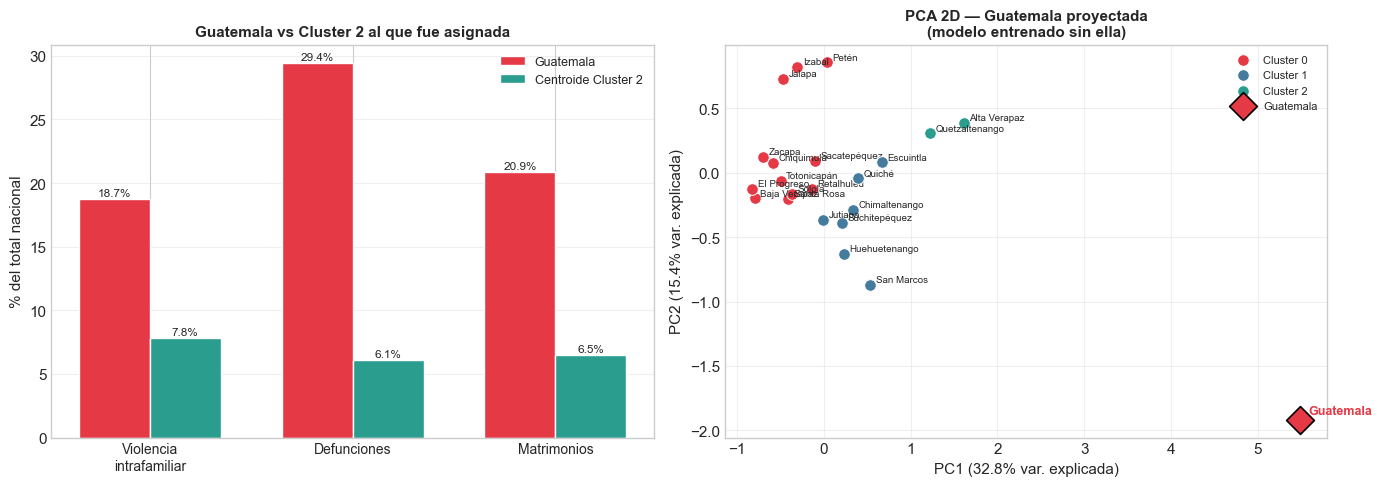


Conclusión: Guatemala queda asignada al Cluster 2.
Sus valores de participación son significativamente más altos que el centroide,
confirmando su carácter de outlier que domina el espacio de features.


In [92]:
print("="*80)
print("G.5 — ASIGNACIÓN DE GUATEMALA AL CLUSTERING (k=3, sin reentrenar)")
print("="*80)
print("Guatemala fue excluida del entrenamiento para no distorsionar los centroides.")
print("Aquí se proyecta sobre el modelo ya ajustado usando predict().\n")

# Features de Guatemala (mismas 18 columnas, misma escala MinMaxScaler ajustada en X_sgt)
gt_features = df_features.loc[['Guatemala'], FEAT_COLS_SGT]
scaler_sgt  = MinMaxScaler().fit(df_feat_sgt[FEAT_COLS_SGT].values)
gt_scaled   = scaler_sgt.transform(gt_features.values)
gt_cluster  = int(km_sgt.predict(gt_scaled)[0])

print(f"Guatemala → asignada al Cluster {gt_cluster}")
print(f"\nDepartamentos de ese cluster (entrenamiento): "
      f"{', '.join(df_feat_sgt[df_feat_sgt['Cluster'] == gt_cluster].index.tolist())}")

# Comparación Guatemala vs centroide de su cluster
centroide = perfil_sgt.loc[gt_cluster]
gt_perfil  = gt_features.iloc[0]
clave_cmp  = {
    'Vio_Promedio_Pct': 'Violencia % nac. promedio',
    'Def_Promedio_Pct': 'Defunciones % nac. promedio',
    'Mat_Promedio_Pct': 'Matrimonios % nac. promedio',
    'Vio_CAGR_Pct'    : 'Violencia CAGR %',
    'Def_CAGR_Pct'    : 'Defunciones CAGR %',
    'Mat_CAGR_Pct'    : 'Matrimonios CAGR %',
    'Vio_CV_Pct'      : 'Violencia CV %',
    'Mat_CV_Pct'      : 'Matrimonios CV %',
}
print(f"\n{'Métrica':<35} {'Guatemala':>12}  {'Centroide C'+str(gt_cluster):>14}  {'Diferencia':>12}")
print("─"*75)
for col, etq in clave_cmp.items():
    if col not in gt_perfil.index:
        continue
    gv  = gt_perfil[col]
    cv  = centroide[col]
    dif = gv - cv
    flecha = '▲' if dif > 0 else '▼'
    print(f"  {etq:<33} {gv:>12.2f}  {cv:>14.2f}  {flecha} {abs(dif):>8.2f}")

# ── Gráfica: Guatemala vs resto del cluster asignado ────────────────────────
avg_cols_cmp  = ['Vio_Promedio_Pct', 'Def_Promedio_Pct', 'Mat_Promedio_Pct']
labels_cmp    = ['Violencia\nintrafamiliar', 'Defunciones', 'Matrimonios']

# Construir dataframe completo con Guatemala marcada
df_full = df_feat_sgt[FEAT_COLS_SGT + ['Cluster']].copy()
df_full.loc['Guatemala'] = list(gt_features.iloc[0]) + [gt_cluster]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: barras comparativas Guatemala vs centroide del cluster
ax = axes[0]
x  = np.arange(len(avg_cols_cmp))
w  = 0.35
gt_vals  = [gt_perfil[c] for c in avg_cols_cmp]
cen_vals = [centroide[c] for c in avg_cols_cmp]
b1 = ax.bar(x - w/2, gt_vals,  width=w, color='#E63946', label='Guatemala',
            edgecolor='white')
b2 = ax.bar(x + w/2, cen_vals, width=w, color=CLUSTER_COLORS[gt_cluster],
            label=f'Centroide Cluster {gt_cluster}', edgecolor='white')
for bar, val in zip(list(b1)+list(b2), gt_vals+cen_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=8.5)
ax.set_title(f'Guatemala vs Cluster {gt_cluster} al que fue asignada',
             fontsize=11, fontweight='bold')
ax.set_ylabel('% del total nacional'); ax.set_xticks(x)
ax.set_xticklabels(labels_cmp, fontsize=10)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='y')

# Panel 2: PCA 2D con Guatemala superpuesta
ax2 = axes[1]
for c in range(K_SGT):
    mask_c = df_pca_sgt['Cluster'] == c
    sub_c  = df_pca_sgt[mask_c]
    ax2.scatter(sub_c['PC1'], sub_c['PC2'],
                color=CLUSTER_COLORS[c], s=70, zorder=3,
                label=f'Cluster {c}', edgecolors='white', lw=0.7)
    for dep, row in sub_c.iterrows():
        ax2.annotate(dep, (row['PC1'], row['PC2']),
                     textcoords='offset points', xytext=(4, 2), fontsize=7)

# Proyectar Guatemala en el PCA entrenado
gt_pca = pca_sgt.transform(gt_scaled)
ax2.scatter(gt_pca[0, 0], gt_pca[0, 1],
            color='#E63946', s=200, marker='D', zorder=5,
            edgecolors='black', lw=1.2, label='Guatemala')
ax2.annotate('Guatemala', (gt_pca[0, 0], gt_pca[0, 1]),
             textcoords='offset points', xytext=(6, 4),
             fontsize=9, fontweight='bold', color='#E63946')
ax2.set_title('PCA 2D — Guatemala proyectada\n(modelo entrenado sin ella)',
              fontsize=11, fontweight='bold')
ax2.set_xlabel(f'PC1 ({var1_sgt:.1f}% var. explicada)')
ax2.set_ylabel(f'PC2 ({var2_sgt:.1f}% var. explicada)')
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nConclusión: Guatemala queda asignada al Cluster {gt_cluster}.")
print("Sus valores de participación son significativamente más altos que el centroide,")
print("confirmando su carácter de outlier que domina el espacio de features.")


G.6 — VISUALIZACIÓN DE CLUSTERS  (espacio de features reales, sin PCA)


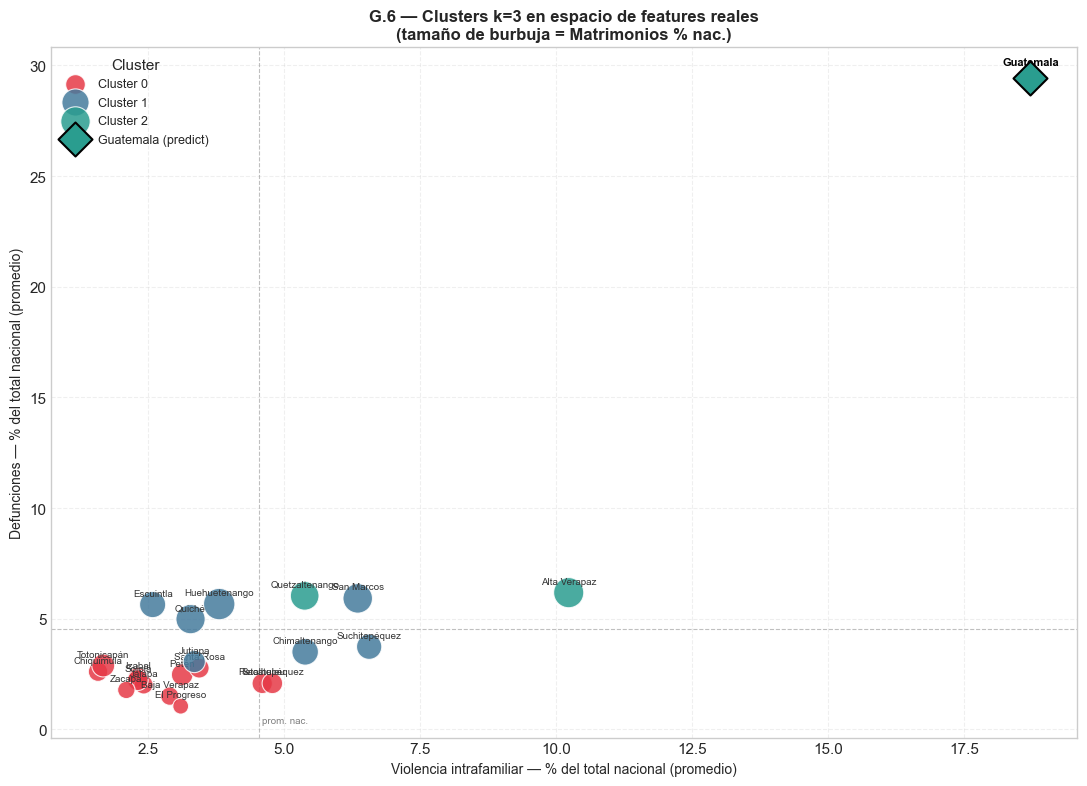

In [94]:

# ── G.6 — Clusters en espacio de features reales (sin PCA) ────────────────
print("="*80)
print("G.6 — VISUALIZACIÓN DE CLUSTERS  (espacio de features reales, sin PCA)")
print("="*80)

# df_full tiene las 18 features + Cluster para los 22 deptos (incl. Guatemala)
x_col = 'Vio_Promedio_Pct'
y_col = 'Def_Promedio_Pct'
s_col = 'Mat_Promedio_Pct'

fig, ax = plt.subplots(figsize=(11, 8))

for ci in range(K_SGT):
    sub_c = df_full[df_full['Cluster'] == ci]
    is_gt = sub_c.index.isin(['Guatemala'])
    # departamentos normales
    normal = sub_c[~is_gt]
    sizes  = (normal[s_col] * 60 + 60).clip(lower=40)
    ax.scatter(normal[x_col], normal[y_col],
               s=sizes, c=CLUSTER_COLORS[ci], alpha=0.85,
               edgecolors='white', linewidths=0.8,
               label=f'Cluster {ci}', zorder=3)
    for dep, row_n in normal.iterrows():
        ax.annotate(dep, (row_n[x_col], row_n[y_col]),
                    fontsize=7, ha='center', va='bottom',
                    xytext=(0, 5), textcoords='offset points', color='#333')

# Guatemala separada con marcador diamante
gt_row = df_full.loc['Guatemala']
gt_c   = int(gt_row['Cluster'])
ax.scatter(gt_row[x_col], gt_row[y_col],
           s=300, c=CLUSTER_COLORS[gt_c],
           marker='D', edgecolors='black', linewidths=1.5,
           zorder=5, label='Guatemala (predict)')
ax.annotate('Guatemala', (gt_row[x_col], gt_row[y_col]),
            fontsize=8, fontweight='bold', ha='center', va='bottom',
            xytext=(0, 8), textcoords='offset points', color='black')

ax.axvline(df_full[x_col].mean(), color='gray', lw=0.8, ls='--', alpha=0.5)
ax.axhline(df_full[y_col].mean(), color='gray', lw=0.8, ls='--', alpha=0.5)
ax.text(df_full[x_col].mean() + 0.05, ax.get_ylim()[0] if ax.get_ylim()[0] > 0 else 0.2,
        'prom. nac.', fontsize=7, color='gray', va='bottom')

ax.set_xlabel('Violencia intrafamiliar — % del total nacional (promedio)', fontsize=10)
ax.set_ylabel('Defunciones — % del total nacional (promedio)', fontsize=10)
ax.set_title(f'G.6 — Clusters k={K_SGT} en espacio de features reales\n'
             f'(tamaño de burbuja = Matrimonios % nac.)', fontsize=12, fontweight='bold')

handles, labels_leg = ax.get_legend_handles_labels()
ax.legend(handles, labels_leg, title='Cluster', fontsize=9,
          loc='upper left', framealpha=0.9)

ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()
